##**Hypothesis Prove**
###Visuaization
####**Upload Data**
1. epistemic_subgraph_with_communities2.pkl
2. sources_withAll_steps_v2_LABELED.csv
3. epistemic_subgraph_with_centralities2.pkl
4. epistemic_layout2.pkl

In [ ]:
from google.colab import files
import os


uploaded = files.upload()
uploaded = files.upload()
uploaded = files.upload()
uploaded = files.upload()

Saving epistemic_subgraph_with_centralities2.pkl to epistemic_subgraph_with_centralities2.pkl


Saving epistemic_subgraph_with_communities2.pkl to epistemic_subgraph_with_communities2.pkl


Saving epistemic_layout2.pkl to epistemic_layout2.pkl


Saving sources_withAll_steps_v2_LABELED.csv to sources_withAll_steps_v2_LABELED.csv


####**Import Libraries**
1. matplotlib
2. matplotlib.pyplot
3. matplotlib.patches
4. numpy
5. igraph
6. os

In [ ]:
!pip install igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 43.7 MB/s eta 0:00:00


In [ ]:
import os, pickle, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from IPython.display import display, Image
import igraph as ig

# Inline display in Colab
%matplotlib inline
mpl.rcParams['figure.dpi'] = 120
print('All libraries imported successfully')

All libraries imported successfully


####**GLobal Design**
Description:
---
Shared design constants for all 5 hypothesis figures (H1–H5). Import this module in each figure script.

----
Design approach:
- Font: DejaVu Sans — available on all platforms without install, clean sans-serif reduces visual noise (Tufte, data-ink ratio).
- Font size 11 body / 13 title: readable at A4 print size (>=9pt).
- Muted palette (low saturation HSL): avoids simultaneous contrast artifacts, low-chroma colours are perceptually uniform across CIE-Lab space.
- Max 5 categorical hues: respects discriminability limit <=7.
- Consistent step-colour mapping across all figures: viewer builds
one mental model, reducing cognitive load design rules).
- Background #F9F7F4 (warm off-white): reduces glare vs pure white improves contrast for coloured elements without harsh luminance jump.
- Spines top/right removed: follows Tufte chartjunk principle and "minimum ink" guideline.
- Annotation boxes with rounded corners + alpha: distinct from data layer without competing with it.


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Name:        design_system.py
Description: Unified design tokens for epistemic citation network figures.
             Updated to match reliable_sources_graph3.pdf reference style:
             white background, red/yellow/blue node palette,
             dashed red + yellow trust triangle edges,
             clear light-grey citation edges.
Author:      student
Date:        2026-05-09
Version:     2.0
"""

import matplotlib as mpl

# ── Typography ────────────────────────────────────────────────────────────────
FONT_FAMILY   = 'DejaVu Sans'   # cross-platform, no install required
FONT_TITLE    = 13              # figure title
FONT_SUBTITLE = 10              # subtitle / panel label
FONT_BODY     = 10              # axis labels, legend text
FONT_SMALL    = 8.5             # annotations, footnotes
FONT_TINY     = 7.5             # source line

# ── Background ────────────────────────────────────────────────────────────────
BG_FIGURE    = '#FFFFFF'        # ← white (was warm off-white #F9F7F4)
BG_AXES      = '#FFFFFF'        # pure white axes area
BG_BOX_GREEN = '#EDF5E8'        # annotation box — confirmed result
BG_BOX_RED   = '#FAEAE9'        # annotation box — refuted / warning
BG_BOX_BLUE  = '#EAF0F9'        # annotation box — neutral info
BG_BOX_AMBER = '#FDF4E3'        # annotation box — note / caution

EDGE_GREEN   = '#A8C99A'
EDGE_RED     = '#D4807A'
EDGE_BLUE    = '#8AAED4'
EDGE_AMBER   = '#D4AD6A'

# ── Step colours — full-saturation palette ────────────────────────────────────
# Used in scatter / bar charts where each step needs a clear distinct hue.
STEP_COLOR = {
    1: '#C5694F',   # muted terracotta  — Step 1 Direct Sources
    2: '#C49A3C',   # muted amber/ochre — Step 2 Mediators
    3: '#4A7FB5',   # muted steel blue  — Step 3 Authorities
    4: '#7B62A3',   # muted violet      — Step 4 Mediated
    5: '#B0ABA4',   # warm mid-grey     — Step 5 Peripheral
}

# ── Step colours — SOFT semi-transparent palette ──────────────────────────────
# Use for network node fills where overlap readability matters.
# Each colour is a pale tint; pair with STEP_EDGE_SOFT for the border.
STEP_COLOR_SOFT = {
    1: '#EDADA0',   # pale terracotta
    2: '#EDD498',   # pale amber
    3: '#A4BED8',   # pale steel blue
    4: '#C4B8DC',   # pale violet
    5: '#D2CEC8',   # pale warm grey
}
STEP_EDGE_SOFT = {
    1: '#B05040',   # darker terracotta border
    2: '#A88020',   # darker amber border
    3: '#3060A0',   # darker blue border
    4: '#6050A0',   # darker violet border
    5: '#807870',   # darker grey border
}

STEP_COLOR_LIGHT = {
    1: '#F2D5CC',
    2: '#F5E8C0',
    3: '#C9DBEE',
    4: '#D9D0EC',
    5: '#E5E3E0',
}
STEP_NAME = {
    1: 'Step 1 — Direct Sources',
    2: 'Step 2 — Mediators',
    3: 'Step 3 — Authorities',
    4: 'Step 4 — Mediated',
    5: 'Step 5 — Peripheral',
}

# ── Reliability tier colours (H5 Trust Triangle) ──────────────────────────────
# Matches reliable_sources_graph3.pdf reference exactly.
REL_STRICT_COLOR = '#D62728'    # ← red   (was deep muted #B03A2E)
REL_STRICT_EDGE  = '#1C1C1C'    # ← black border (was dark red #7B241C)
REL_SOFT_COLOR   = '#F5C518'    # ← yellow (was forest green #1E8449)
REL_SOFT_EDGE    = '#1C1C1C'    # ← black border (was dark green #145A32)
REL_OTHER_COLOR  = '#4472C4'    # ← mid-blue (was Step 2 amber)
REL_OTHER_EDGE   = '#2A4A8A'    # ← darker blue border

# Step 1 nodes in Trust Triangle view: blue + black border (same as REL_OTHER
# but kept as separate tokens so each role can be tuned independently)
STEP1_NODE_COLOR = '#4472C4'    # blue — Step 1 direct sources
STEP1_NODE_EDGE  = '#1C1C1C'    # black border

# Step 3 nodes in Trust Triangle view: light grey + mid-grey border
STEP3_NODE_COLOR = '#D8D8D8'    # light grey — Step 3 authorities
STEP3_NODE_EDGE  = '#909090'    # mid-grey border

# ── Accent / highlight ────────────────────────────────────────────────────────
ACCENT_RED      = '#C0392B'     # strong alert / refuted
ACCENT_GREEN    = '#27AE60'     # confirmed result
ACCENT_NEUTRAL  = '#566573'     # neutral annotation text

# ── Network edge colours ──────────────────────────────────────────────────────
EDGE_GRAY            = '#C8C8C8'    # ← clear light grey (was #DEDBD6)
                                    #   matches the crisp grey edges in reference
EDGE_HIGHLIGHT       = '#E8A09A'    # soft salmon — kept for backward compat

# Trust Triangle edges — two types, drawn as dashed arrows
EDGE_TRIANGLE_RED    = '#D62728'    # strict reliable triangle (red dashed)
EDGE_TRIANGLE_YELLOW = '#E8A800'    # candidate triangle       (yellow/amber dashed)

# ── Scatter / marker ──────────────────────────────────────────────────────────
SCATTER_ALPHA = 0.72
SCATTER_EDGE  = 'white'
SCATTER_LW    = 0.4

# ── Spine / grid helpers ──────────────────────────────────────────────────────
GRID_COLOR  = '#EBEBEB'
SPINE_COLOR = '#CCCCCC'

# ── Source footer text ────────────────────────────────────────────────────────
FOOTER = ('Sources: epistemic_subgraph_with_communities2.pkl  |  '
          'sources_withAll_steps_v2_LABELED.csv  |  '
          'All publications uniquely identifiable via DOI.')


# ── Global theme ──────────────────────────────────────────────────────────────
def apply_theme():
    """
    Call once at the top of each figure script to apply global Matplotlib style.
    Sets white background, clean spines, subtle grid, and consistent typography.
    """
    mpl.rcParams.update({
        'font.family':           FONT_FAMILY,
        'font.size':             FONT_BODY,
        'axes.titlesize':        FONT_SUBTITLE,
        'axes.labelsize':        FONT_BODY,
        'xtick.labelsize':       FONT_BODY,
        'ytick.labelsize':       FONT_BODY,
        'legend.fontsize':       FONT_SMALL,
        'legend.title_fontsize': FONT_BODY,
        'figure.facecolor':      BG_FIGURE,   # white
        'axes.facecolor':        BG_AXES,     # white
        'axes.edgecolor':        SPINE_COLOR,
        'axes.grid':             True,
        'grid.color':            GRID_COLOR,
        'grid.linewidth':        0.5,
        'axes.spines.top':       False,
        'axes.spines.right':     False,
        'axes.spines.left':      True,
        'axes.spines.bottom':    True,
        'axes.linewidth':        0.6,
        'xtick.direction':       'out',
        'ytick.direction':       'out',
        'savefig.facecolor':     BG_FIGURE,
        'savefig.dpi':           180,
        'savefig.bbox':          'tight',
        'figure.dpi':            100,
    })


# ── Annotation helper ─────────────────────────────────────────────────────────
def annotation_box(ax, x, y, text, style='info', fontsize=None,
                   ha='left', va='top', transform=None):
    """
    Draw a rounded annotation box on ax.

    Parameters
    ----------
    style : str
        'confirm' — green box  (confirmed hypothesis)
        'warn'    — red box    (refuted / warning)
        'info'    — blue box   (neutral information)
        'note'    — amber box  (caution / side note)
    """
    styles = {
        'confirm': (BG_BOX_GREEN, EDGE_GREEN),
        'warn':    (BG_BOX_RED,   EDGE_RED),
        'info':    (BG_BOX_BLUE,  EDGE_BLUE),
        'note':    (BG_BOX_AMBER, EDGE_AMBER),
    }
    fc, ec = styles.get(style, styles['info'])
    fs = fontsize or FONT_SMALL
    tr = transform or ax.transAxes
    ax.text(x, y, text, transform=tr, fontsize=fs, ha=ha, va=va,
            color='#2C3E50', linespacing=1.45,
            bbox=dict(boxstyle='round,pad=0.45', facecolor=fc,
                      edgecolor=ec, linewidth=0.8, alpha=0.92))


# ── Footer helper ─────────────────────────────────────────────────────────────
def footer(fig, text=None):
    """Add a source/data-credit footer centred at the bottom of the figure."""
    fig.text(0.5, 0.008, text or FOOTER,
             ha='center', fontsize=FONT_TINY,
             color='#888888', fontstyle='italic')

---
## Load Graph Data
Run once — reused by H2–H5.

In [ ]:
# Load all graph pkl files (run once)

with open('epistemic_subgraph_with_communities2.pkl', 'rb') as f:
    g_comm = pickle.load(f)
with open('epistemic_subgraph_with_centralities2.pkl', 'rb') as f:
    g_cent = pickle.load(f)
with open('epistemic_layout2.pkl', 'rb') as f:
    layout = pickle.load(f)

coords = np.array(layout.coords)
bet    = np.array(g_cent.vs['betweenness'])
eig    = np.array(g_cent.vs['eigenvector'])
indeg  = np.array(g_cent.indegree())
steps  = np.array(g_cent.vs['step_distance'])
names  = [v['name'] for v in g_cent.vs]

idx1 = np.where(steps == 1)[0]
idx2 = np.where(steps == 2)[0]
idx3 = np.where(steps == 3)[0]

# Trust Triangle pre-computation (used by H5)
indeg_thr   = np.percentile(indeg, 90)
step1_set   = {v.index for v in g_comm.vs if v['step_distance'] == 1}
high_indeg  = {v.index for v in g_comm.vs if indeg[v.index] >= indeg_thr}

reliable_strict   = set()
triangle_edge_ids = set()
for a in g_comm.vs:
    a_id = a.index
    if a_id in step1_set or a_id not in high_indeg: continue
    a_s1 = set(g_comm.successors(a_id)) & step1_set
    if not a_s1: continue
    for b_id in high_indeg:
        if b_id == a_id: continue
        b_s1 = set(g_comm.successors(b_id)) & a_s1
        if not b_s1: continue
        if g_comm.are_adjacent(a_id, b_id) or g_comm.are_adjacent(b_id, a_id):
            reliable_strict.add(a_id); reliable_strict.add(b_id)
            s = next(iter(b_s1))
            for x, y in [(a_id, b_id), (a_id, s), (b_id, s)]:
                eid = g_comm.get_eid(x, y, directed=False, error=False)
                if eid != -1: triangle_edge_ids.add(eid)
            break

scores = []
for v in g_comm.vs:
    vid = v.index
    if vid in step1_set: continue
    sc = 0
    a_s1 = set(g_comm.successors(vid)) & step1_set
    if a_s1: sc += 1
    if vid in high_indeg: sc += 1
    for u in high_indeg:
        if u == vid: continue
        if (g_comm.are_adjacent(vid, u) or g_comm.are_adjacent(u, vid)):
            if set(g_comm.successors(u)) & a_s1: sc += 1; break
    scores.append((vid, sc, indeg[vid]))

top10_all = [vid for vid, sc, d in
             sorted(scores, key=lambda x: (x[1], x[2]), reverse=True)
             if sc >= 2][:10]
soft4 = [vid for vid in top10_all if vid not in reliable_strict][:4]

print(f'Graph loaded: {g_comm.vcount()} nodes, {g_comm.ecount()} edges')
print(f'Strict reliable: {len(reliable_strict)}')
print(f'  ' + ', '.join(g_comm.vs[v]['name'] for v in reliable_strict))
print(f'Soft reliable top-4: {len(soft4)}')

Graph loaded: 400 nodes, 841 edges
Strict reliable: 2
  Robson2001_TheTabletH, George0000_InSearchOf
Soft reliable top-4: 4


####**Hypothesis 1**  
> Is knowledge distribution hierarchical (tree-like)?


**Figure Description**:

---


Bar chart (distribution by step) + Donut chart (proportional view). Uses soft muted palette. Design approach in design_system.py.

---


**Input files**: `sources_withAll_steps_v2_LABELED.csv`

(same folder OR edit PATHS below)

**Output**: `figure1_H1.png`

---

**Dependencies** (all standard — no extra install needed): `matplotlib`,  `numpy`, `pandas`.






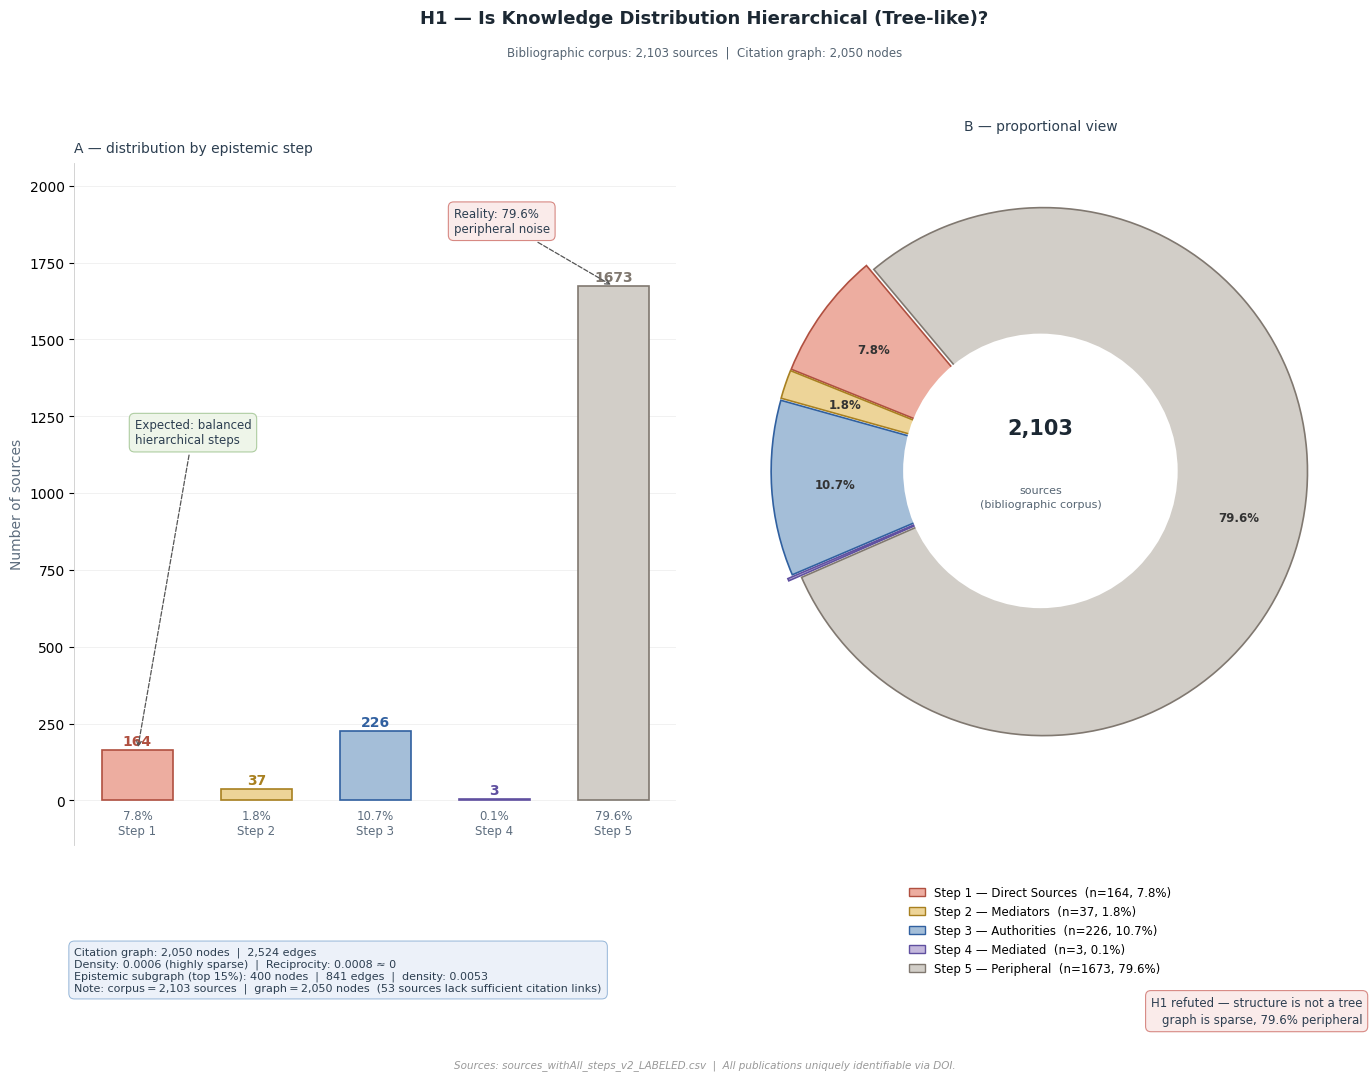

Saved → figure1_H1.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — H1
# Run after: Cell 1 (imports) → Cell 2 (upload) → Cell 3 (design system)


def add_footer(fig, text=None):
    """Add italic source line at the very bottom of the figure."""
    default = ('Sources: sources_withAll_steps_v2_LABELED.csv  |  '
               'All publications uniquely identifiable via DOI.')
    fig.text(0.5, 0.018, text or default,
             ha='center', fontsize=FONT_TINY,
             color='#999999', fontstyle='italic')

def show_and_save(fig, filename):
    """Save figure as PNG and display it inline in Colab / Jupyter."""
    fig.savefig(filename, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f'Saved \u2192 {filename}')

apply_theme()

# ── Data ──────────────────────────────────────────────────────────────────
df = pd.read_csv('sources_withAll_steps_v2_LABELED.csv', sep=',', on_bad_lines='skip')

# Count sources per step from CSV
full = {s: int((df['step_distance_v2'] == float(s)).sum()) for s in [1, 2, 3, 4, 5]}

# Fix 1: two separate counts, used in different places
CSV_TOTAL   = sum(full.values())   # 2103 — what the bar/donut actually shows
GRAPH_NODES = 2050                 # nodes in directed citation graph (from pkl)
GRAPH_EDGES = 2524
BG_WHITE    = '#FFFFFF'

# Soft semi-transparent step colours + matching darker border
STEP_COLOR_SOFT = {
    1: '#EDADA0',   # pale terracotta
    2: '#EDD498',   # pale amber
    3: '#A4BED8',   # pale steel blue
    4: '#C4B8DC',   # pale violet
    5: '#D2CEC8',   # pale warm grey
}
STEP_EDGE_SOFT = {
    1: '#B05040',
    2: '#A88020',
    3: '#3060A0',
    4: '#6050A0',
    5: '#807870',
}

# ── Figure and axes ───────────────────────────────────────────────────────
fig    = plt.figure(figsize=(14, 11))
fig.patch.set_facecolor(BG_WHITE)

ax_bar = fig.add_axes([0.05, 0.22, 0.43, 0.62])   # bar chart — left
ax_do  = fig.add_axes([0.52, 0.26, 0.44, 0.60])   # donut    — right

# ── Main title ────────────────────────────────────────────────────────────
fig.text(0.5, 0.967,
         'H1 \u2014 Is Knowledge Distribution Hierarchical (Tree-like)?',
         ha='center', fontsize=FONT_TITLE, fontweight='bold', color='#1C2833')

# Fix 1: subtitle shows BOTH numbers clearly, no duplication
fig.text(0.5, 0.937,
         f'Bibliographic corpus: {CSV_TOTAL:,} sources  |  '
         f'Citation graph: {GRAPH_NODES:,} nodes',
         ha='center', fontsize=FONT_SMALL, color=ACCENT_NEUTRAL)

# ══════════════════════════════════════════════════════════════════════════
# PANEL A — Bar chart
# ══════════════════════════════════════════════════════════════════════════
ax_bar.set_facecolor(BG_WHITE)
ax_bar.set_title('A \u2014 distribution by epistemic step',
                 fontsize=FONT_SUBTITLE, loc='left', pad=8, color='#2C3E50')

steps_list = [1, 2, 3, 4, 5]
counts     = [full[s] for s in steps_list]
x_pos      = np.arange(5)

bars = ax_bar.bar(
    x_pos, counts, width=0.60,
    color   =[STEP_COLOR_SOFT[s] for s in steps_list],
    edgecolor=[STEP_EDGE_SOFT[s]  for s in steps_list],
    linewidth=1.2, zorder=3
)

# Value labels above each bar
for bar, val, s in zip(bars, counts, steps_list):
    ax_bar.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 16,
                f'{val}',
                ha='center', fontsize=FONT_BODY,
                fontweight='bold', color=STEP_EDGE_SOFT[s])
    ax_bar.text(bar.get_x() + bar.get_width() / 2,
                -110,
                f'{100 * val / CSV_TOTAL:.1f}%\n'
                f'{STEP_NAME[s].split(chr(8212))[0].strip()}',
                ha='center', fontsize=FONT_SMALL, color='#5D6D7E')

ax_bar.set_xticks([])
ax_bar.set_ylabel('Number of sources', fontsize=FONT_BODY, color='#5D6D7E')
ax_bar.set_ylim(-145, max(counts) * 1.24)
ax_bar.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, zorder=0)
ax_bar.set_axisbelow(True)
ax_bar.spines['bottom'].set_visible(False)
ax_bar.set_facecolor(BG_WHITE)

# ── Fix 2: annotation boxes + arrows connected to bar tops ────────────────
# Key technique: ax.annotate(text, xy=bar_top, xytext=box_position)
# - xy       = arrowhead destination  → data coords (exact bar top)
# - xytext   = text/box position      → axes fraction (easy to position)
# - arrowprops: matplotlib auto-connects from edge of bbox to xy

b1 = bars[0]   # Step 1 bar
b5 = bars[4]   # Step 5 bar

# Arrow target: top-centre of each bar in data coordinates
s1_head_x = b1.get_x() + b1.get_width() / 2   # x-centre Step1
s1_head_y = b1.get_height()                     # y = top   Step1
s5_head_x = b5.get_x() + b5.get_width() / 2   # x-centre Step5
s5_head_y = b5.get_height()                     # y = top   Step5

# "Expected" green box — connects to Step 1 bar top
ax_bar.annotate(
    'Expected: balanced\nhierarchical steps',
    xy      =(s1_head_x, s1_head_y),   # HEAD: Step1 bar top (data coords)
    xytext  =(0.10, 0.625),            # TAIL: box position  (axes fraction)
    xycoords='data',
    textcoords='axes fraction',
    fontsize=FONT_SMALL,
    color='#2C3E50',
    ha='left', va='top',
    bbox=dict(boxstyle='round,pad=0.45', facecolor=BG_BOX_GREEN,
              edgecolor=EDGE_GREEN, linewidth=0.8, alpha=0.92),
    arrowprops=dict(
        arrowstyle='->', color='#555555', lw=0.9,
        linestyle='dashed',
        connectionstyle='arc3,rad=0.0'   # straight dashed line
    )
)

# "Reality" red box — connects to Step 5 bar top
ax_bar.annotate(
    f'Reality: {100 * full[5] / CSV_TOTAL:.1f}%\nperipheral noise',
    xy      =(s5_head_x, s5_head_y),   # HEAD: Step5 bar top (data coords)
    xytext  =(0.63, 0.935),            # TAIL: box position  (axes fraction)
    xycoords='data',
    textcoords='axes fraction',
    fontsize=FONT_SMALL,
    color='#2C3E50',
    ha='left', va='top',
    bbox=dict(boxstyle='round,pad=0.45', facecolor=BG_BOX_RED,
              edgecolor=EDGE_RED, linewidth=0.8, alpha=0.92),
    arrowprops=dict(
        arrowstyle='->', color='#555555', lw=0.9,
        linestyle='dashed',
        connectionstyle='arc3,rad=0.0'   # straight dashed line
    )
)

# ══════════════════════════════════════════════════════════════════════════
# PANEL B — Donut chart
# ══════════════════════════════════════════════════════════════════════════
ax_do.set_facecolor(BG_WHITE)
ax_do.set_title('B \u2014 proportional view',
                fontsize=FONT_SUBTITLE, loc='center', pad=8, color='#2C3E50')
ax_do.axis('equal')
ax_do.set_xticks([]); ax_do.set_yticks([])
for sp in ax_do.spines.values():
    sp.set_visible(False)
ax_do.grid(False)

wedges, texts, autotexts = ax_do.pie(
    [full[s] for s in steps_list],
    colors   =[STEP_COLOR_SOFT[s] for s in steps_list],
    explode  =(0.02, 0.02, 0.02, 0.04, 0.012),
    autopct  =lambda p: f'{p:.1f}%' if p > 1.2 else '',
    startangle=130,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    pctdistance=0.76,
    textprops={'fontsize': FONT_SMALL}
)

# Apply per-wedge coloured border in a loop (cannot pass list to wedgeprops)
for w, s in zip(wedges, steps_list):
    w.set_edgecolor(STEP_EDGE_SOFT[s])
    w.set_linewidth(1.2)

# Percentage labels: dark text readable on soft fill
for at in autotexts:
    at.set_fontweight('bold')
    at.set_color('#333333')

# Donut hole
hole = plt.Circle((0, 0), 0.52, fc=BG_WHITE)
ax_do.add_artist(hole)

# Fix 1: centre label = CSV_TOTAL (2103) — matches the pie slice data
ax_do.text(0,  0.16, f'{CSV_TOTAL:,}',
           ha='center', va='center',
           fontsize=15, fontweight='bold', color='#1C2833')
ax_do.text(0, -0.10, 'sources\n(bibliographic corpus)',
           ha='center', va='center',
           fontsize=FONT_SMALL - 0.5, color=ACCENT_NEUTRAL, linespacing=1.4)

# Legend — placed below donut via bbox_to_anchor
ax_do.legend(
    handles=[
        mpatches.Patch(
            facecolor=STEP_COLOR_SOFT[s],
            edgecolor=STEP_EDGE_SOFT[s],
            linewidth=1.0,
            label=f'{STEP_NAME[s]}  (n={full[s]}, {100 * full[s] / CSV_TOTAL:.1f}%)'
        ) for s in steps_list
    ],
    loc='lower center', bbox_to_anchor=(0.5, -0.28),
    fontsize=FONT_SMALL, frameon=False, ncol=1, handlelength=1.3
)

# ── Fix 3: H1-refuted badge at bottom-right of figure ────────────────────
# Placed with fig.text at fixed (x=0.97, y=0.055) — always above footer (y=0.018)
# Cannot overlap donut legend because it is in a different figure region
fig.text(
    0.97, 0.055,
    'H1 refuted \u2014 structure is not a tree\n'
    'graph is sparse, 79.6% peripheral',
    ha='right', va='bottom',
    fontsize=FONT_SMALL, color='#2C3E50', linespacing=1.45,
    bbox=dict(boxstyle='round,pad=0.45', facecolor=BG_BOX_RED,
              edgecolor=EDGE_RED, linewidth=0.8, alpha=0.92)
)

# ── Metrics box (bottom-left) ─────────────────────────────────────────────
# Fix 1: "GRAPH_NODES = 2050" lives ONLY here — no duplication elsewhere
fig.text(
    0.05, 0.085,
    f'Citation graph: {GRAPH_NODES:,} nodes  |  {GRAPH_EDGES:,} edges\n'
    f'Density: 0.0006 (highly sparse)  |  Reciprocity: 0.0008 \u2248 0\n'
    f'Epistemic subgraph (top 15%): 400 nodes  |  841 edges  |  density: 0.0053\n'
    f'Note: corpus\u2009=\u20092,103 sources  |  graph\u2009=\u20092,050 nodes  '
    f'(53 sources lack sufficient citation links)',
    fontsize=FONT_SMALL - 0.5, color='#2C3E50', va='bottom',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#EAF0F9',
              edgecolor='#8AAED4', linewidth=0.7, alpha=0.9)
)

# ── Footer ────────────────────────────────────────────────────────────────
add_footer(fig)
show_and_save(fig, 'figure1_H1.png')


####**Hypothesis 2**

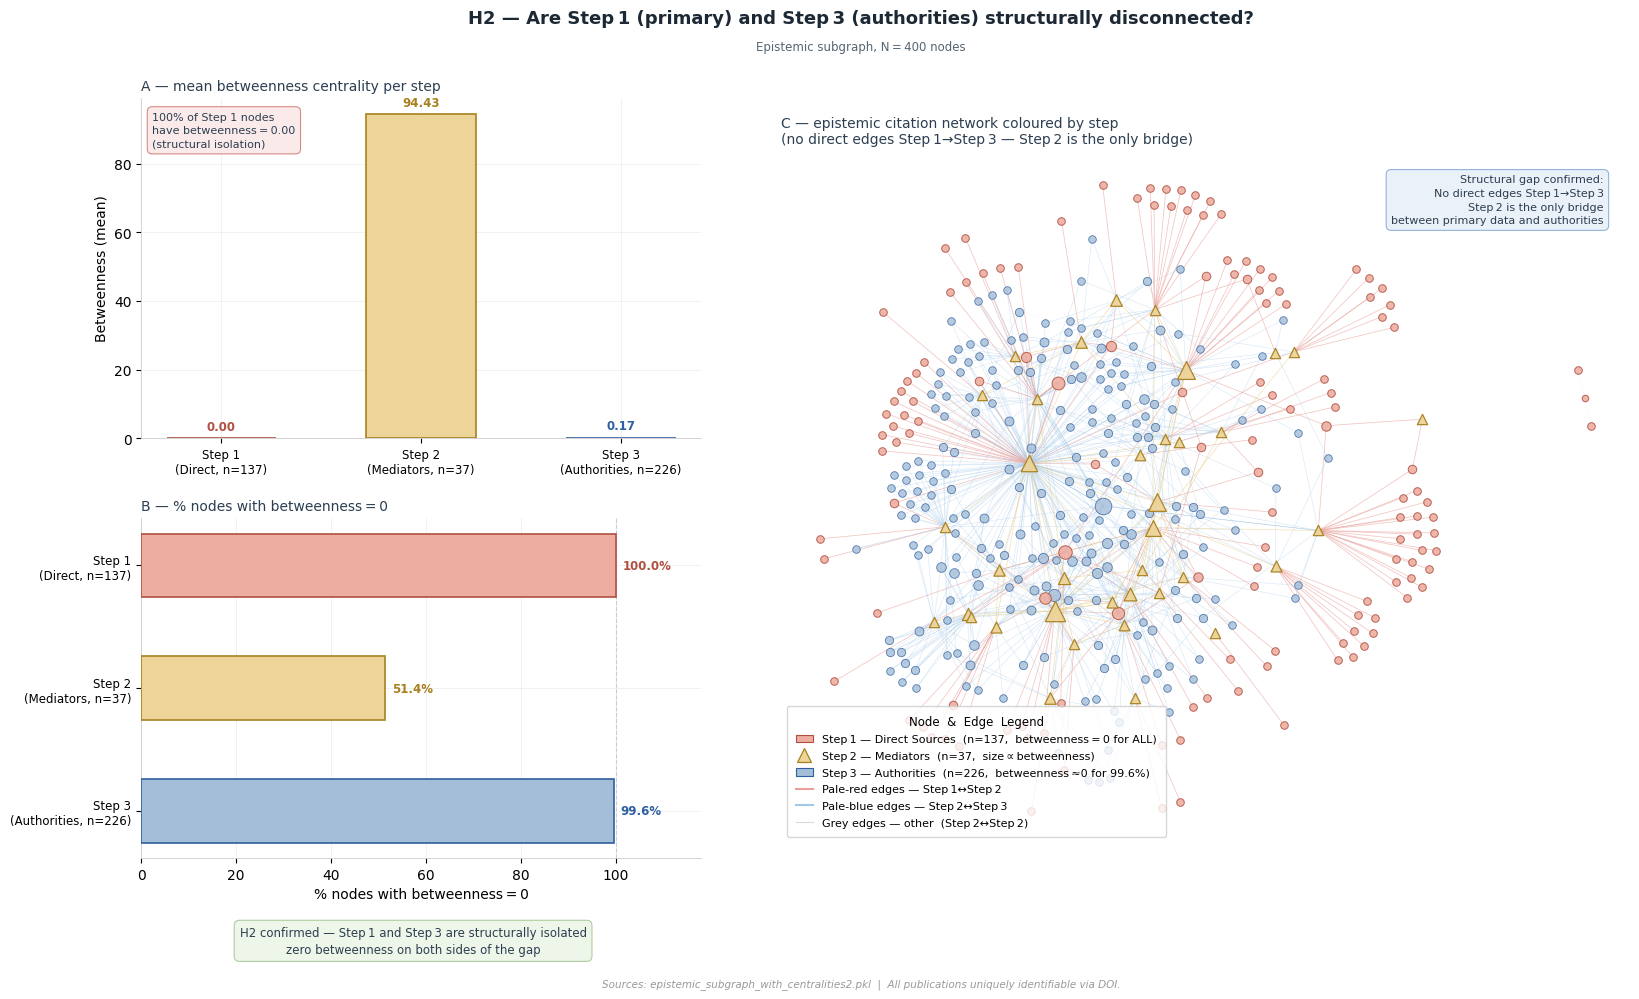

Saved → figure2_H2.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — H2  |  Final version for Google Colab — Cell 6
# Run after: Cell 1 (imports) → Cell 2 (upload) → Cell 3 (design system)
#            → Cell 4 (load graphs: g_comm, g_cent, layout, coords, bet,
#                       indeg, steps, idx1, idx2, idx3)
#
# Changes vs original:
#   1. White background (BG_WHITE instead of BG_FIGURE)
#   2. Soft muted step colours + matching darker border (STEP_COLOR_SOFT)
#   3. Panels C and D replaced by one network graph (panel C):
#        Step 1 = red circles + pale-red edges to Step 2
#        Step 2 = yellow triangles, size proportional to betweenness
#        Step 3 = blue circles + pale-blue edges to Step 2
#        other  = grey nodes and edges
#   4. Layout: A + B stacked on the left, network on the right
#   5. H2-confirmed badge uses fig.text (cannot overlap axes)
# ════════════════════════════════════════════════════════════════════════════

# ── Safety fallbacks — safe to re-run even if Cell 3 already defined them ─
def add_footer(fig, text=None):
    default = ('Sources: epistemic_subgraph_with_centralities2.pkl  |  '
               'All publications uniquely identifiable via DOI.')
    fig.text(0.5, 0.012, text or default,
             ha='center', fontsize=FONT_TINY,
             color='#999999', fontstyle='italic')

def show_and_save(fig, filename):
    fig.savefig(filename, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f'Saved \u2192 {filename}')

apply_theme()

# ── Soft muted colours (same system as Figure 1) ─────────────────────────
BG_WHITE = '#FFFFFF'
STEP_COLOR_SOFT = {
    1: '#EDADA0',   # pale terracotta  — Step 1 Direct Sources
    2: '#EDD498',   # pale amber       — Step 2 Mediators
    3: '#A4BED8',   # pale steel blue  — Step 3 Authorities
}
STEP_EDGE_SOFT = {
    1: '#B05040',
    2: '#A88020',
    3: '#3060A0',
}

# ── Statistics ───────────────────────────────────────────────────────────
means_bet = [bet[idx1].mean(), bet[idx2].mean(), bet[idx3].mean()]
pct_zero  = [100 * (bet[idx] == 0).mean() for idx in [idx1, idx2, idx3]]
ns        = [len(idx1), len(idx2), len(idx3)]
step_lbl  = [
    f'Step {s}\n({["Direct","Mediators","Authorities"][s-1]}, n={ns[s-1]})'
    for s in [1, 2, 3]
]

# ── Figure and axes ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(BG_WHITE)

ax_a   = fig.add_axes([0.05, 0.56, 0.35, 0.34])   # top-left:  bar A
ax_b   = fig.add_axes([0.05, 0.14, 0.35, 0.34])   # bot-left:  bar B
ax_net = fig.add_axes([0.45, 0.08, 0.53, 0.84])   # right:     network

# ── Titles ────────────────────────────────────────────────────────────────
fig.text(0.5, 0.975,
         'H2 \u2014 Are Step\u20091 (primary) and Step\u20093 (authorities) '
         'structurally disconnected?',
         ha='center', fontsize=FONT_TITLE, fontweight='bold', color='#1C2833')
fig.text(0.5, 0.948,
         'Epistemic subgraph, N\u2009=\u2009400 nodes',
         ha='center', fontsize=FONT_SMALL, color=ACCENT_NEUTRAL)

# ══════════════════════════════════════════════════════════════════════════
# PANEL A — Mean betweenness bar
# ══════════════════════════════════════════════════════════════════════════
ax_a.set_facecolor(BG_WHITE)
ax_a.set_title('A \u2014 mean betweenness centrality per step',
               fontsize=FONT_SUBTITLE, loc='left', pad=6, color='#2C3E50')

bars = ax_a.bar(
    [0, 1, 2], means_bet, width=0.55,
    color    =[STEP_COLOR_SOFT[1], STEP_COLOR_SOFT[2], STEP_COLOR_SOFT[3]],
    edgecolor=[STEP_EDGE_SOFT[1],  STEP_EDGE_SOFT[2],  STEP_EDGE_SOFT[3]],
    linewidth=1.2, zorder=3
)
ax_a.set_xticks([0, 1, 2])
ax_a.set_xticklabels(step_lbl, fontsize=FONT_SMALL)
ax_a.set_ylabel('Betweenness (mean)', fontsize=FONT_BODY)
ax_a.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, zorder=0)
ax_a.set_axisbelow(True)
ax_a.set_facecolor(BG_WHITE)

for bar, val in zip(bars, means_bet):
    ax_a.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + max(means_bet) * 0.025,
              f'{val:.2f}', ha='center', fontsize=FONT_SMALL,
              fontweight='bold', color=bar.get_edgecolor())

annotation_box(ax_a, 0.02, 0.96,
               '100% of Step 1 nodes\nhave betweenness\u2009=\u20090.00\n'
               '(structural isolation)',
               style='warn', fontsize=FONT_SMALL - 0.5,
               transform=ax_a.transAxes)

# ══════════════════════════════════════════════════════════════════════════
# PANEL B — % nodes with betweenness = 0
# ══════════════════════════════════════════════════════════════════════════
ax_b.set_facecolor(BG_WHITE)
ax_b.set_title('B \u2014 % nodes with betweenness\u2009=\u20090',
               fontsize=FONT_SUBTITLE, loc='left', pad=6, color='#2C3E50')

h_bars = ax_b.barh(
    [0, 1, 2], pct_zero[::-1],
    color    =[STEP_COLOR_SOFT[3], STEP_COLOR_SOFT[2], STEP_COLOR_SOFT[1]],
    edgecolor=[STEP_EDGE_SOFT[3],  STEP_EDGE_SOFT[2],  STEP_EDGE_SOFT[1]],
    linewidth=1.2, height=0.52, zorder=3
)
ax_b.set_yticks([0, 1, 2])
ax_b.set_yticklabels(step_lbl[::-1], fontsize=FONT_SMALL)
ax_b.set_xlabel('% nodes with betweenness\u2009=\u20090', fontsize=FONT_BODY)
ax_b.set_xlim(0, 118)
ax_b.axvline(100, color=SPINE_COLOR, linewidth=0.8, linestyle='--', zorder=2)
ax_b.xaxis.grid(True, color=GRID_COLOR, linewidth=0.5, zorder=0)
ax_b.set_axisbelow(True)
ax_b.set_facecolor(BG_WHITE)

for bar, val, ec in zip(h_bars, pct_zero[::-1],
                        [STEP_EDGE_SOFT[3], STEP_EDGE_SOFT[2], STEP_EDGE_SOFT[1]]):
    ax_b.text(val + 1.5, bar.get_y() + bar.get_height() / 2,
              f'{val:.1f}%', va='center', fontsize=FONT_SMALL,
              fontweight='bold', color=ec)

# H2 confirmed badge — fig.text: fixed position, never overlaps axes
fig.text(0.22, 0.042,
         'H2 confirmed \u2014 Step\u20091 and Step\u20093 are structurally isolated\n'
         'zero betweenness on both sides of the gap',
         ha='center', va='bottom',
         fontsize=FONT_SMALL, color='#2C3E50', linespacing=1.45,
         bbox=dict(boxstyle='round,pad=0.45',
                   facecolor='#EDF5E8', edgecolor='#A8C99A',
                   linewidth=0.8, alpha=0.92))

# ══════════════════════════════════════════════════════════════════════════
# PANEL C — Citation network coloured by epistemic step
#
# Visual encoding (Munzner: identity channels for categorical data):
#   Step 1  circles, pale terracotta  — primary sources (betweenness = 0)
#   Step 2  triangles, pale amber     — mediators (only bridge layer)
#   Step 3  circles, pale steel blue  — authorities
#
#   Step1↔Step2 edges  pale-red    (shows which mediators touch primary data)
#   Step2↔Step3 edges  pale-blue   (shows which authorities reach mediators)
#   Step2↔Step2 edges  pale-amber  (internal mediator connections)
#   other edges        grey        (background structural context)
#
#   Node size ∝ betweenness for Step 2, ∝ in-degree for Steps 1 and 3
# ══════════════════════════════════════════════════════════════════════════
ax_net.set_facecolor(BG_WHITE)
ax_net.axis('off')
ax_net.set_aspect('equal')
ax_net.set_title(
    'C \u2014 epistemic citation network coloured by step\n'
    '(no direct edges Step\u20091\u2192Step\u20093 \u2014 '
    'Step\u20092 is the only bridge)',
    fontsize=FONT_SUBTITLE, loc='left', pad=8, color='#2C3E50')

# Draw edges first (back layer)
for e in g_comm.es:
    ss = g_comm.vs[e.source]['step_distance']
    ts = g_comm.vs[e.target]['step_distance']
    sx, sy = coords[e.source]
    tx, ty = coords[e.target]

    if   (ss == 1 and ts == 2) or (ss == 2 and ts == 1):
        ec_col, lw, al = '#E8A09A', 0.55, 0.60   # pale-red: Step1↔Step2
    elif (ss == 2 and ts == 3) or (ss == 3 and ts == 2):
        ec_col, lw, al = '#A4C8E8', 0.40, 0.45   # pale-blue: Step2↔Step3
    elif ss == 2 and ts == 2:
        ec_col, lw, al = '#E8C87A', 0.50, 0.55   # amber: Step2↔Step2
    else:
        ec_col, lw, al = '#DDDAD5', 0.25, 0.35   # grey: other

    ax_net.plot([sx, tx], [sy, ty],
                color=ec_col, linewidth=lw, alpha=al, zorder=1)

# Draw nodes: Step3 first (back), then Step1, then Step2 (front)
for i in idx3:
    x, y = coords[i]
    ax_net.scatter(x, y, s=18 + indeg[i] * 6,
                   c=STEP_COLOR_SOFT[3],
                   edgecolors=STEP_EDGE_SOFT[3], linewidths=0.6,
                   alpha=0.80, zorder=3)

for i in idx1:
    x, y = coords[i]
    ax_net.scatter(x, y, s=22 + indeg[i] * 8,
                   c=STEP_COLOR_SOFT[1],
                   edgecolors=STEP_EDGE_SOFT[1], linewidths=0.7,
                   alpha=0.88, zorder=4)

for i in idx2:
    x, y = coords[i]
    ax_net.scatter(x, y, s=55 + bet[i] / 5,   # size encodes betweenness
                   c=STEP_COLOR_SOFT[2], marker='^',
                   edgecolors=STEP_EDGE_SOFT[2], linewidths=0.9,
                   alpha=0.95, zorder=5)

# ── Legend ────────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D   # safe re-import

legend_elements = [
    mpatches.Patch(facecolor=STEP_COLOR_SOFT[1], edgecolor=STEP_EDGE_SOFT[1], lw=0.8,
        label='Step\u20091 \u2014 Direct Sources  '
              '(n=137,  betweenness\u2009=\u20090 for ALL)'),
    Line2D([0], [0], marker='^', color='w',
        markerfacecolor=STEP_COLOR_SOFT[2],
        markeredgecolor=STEP_EDGE_SOFT[2],
        markeredgewidth=0.9, markersize=10,
        label='Step\u20092 \u2014 Mediators  (n=37,  size\u2009\u221d\u2009betweenness)'),
    mpatches.Patch(facecolor=STEP_COLOR_SOFT[3], edgecolor=STEP_EDGE_SOFT[3], lw=0.8,
        label='Step\u20093 \u2014 Authorities  '
              '(n=226,  betweenness\u2009\u22480 for 99.6%)'),
    Line2D([0], [0], color='#E8A09A', lw=1.5,
        label='Pale-red edges \u2014 Step\u20091\u2194Step\u20092'),
    Line2D([0], [0], color='#A4C8E8', lw=1.5,
        label='Pale-blue edges \u2014 Step\u20092\u2194Step\u20093'),
    Line2D([0], [0], color='#DDDAD5', lw=0.8,
        label='Grey edges \u2014 other  (Step\u20092\u2194Step\u20092)'),
]
ax_net.legend(handles=legend_elements,
              loc='lower left', fontsize=FONT_SMALL - 0.5,
              frameon=True, facecolor=BG_WHITE, edgecolor=SPINE_COLOR,
              title='Node  &  Edge  Legend', title_fontsize=FONT_SMALL,
              borderpad=0.8, handlelength=1.6, labelspacing=0.6)

# ── Structural gap annotation cloud ──────────────────────────────────────
ax_net.text(0.97, 0.97,
            'Structural gap confirmed:\n'
            'No direct edges Step\u20091\u2192Step\u20093\n'
            'Step\u20092 is the only bridge\n'
            'between primary data and authorities',
            transform=ax_net.transAxes,
            fontsize=FONT_SMALL - 0.5, ha='right', va='top',
            color='#2C3E50', linespacing=1.45,
            bbox=dict(boxstyle='round,pad=0.45',
                      facecolor='#EAF0F9', edgecolor='#8AAED4',
                      linewidth=0.8, alpha=0.92))

# ── Footer ────────────────────────────────────────────────────────────────
add_footer(fig)
show_and_save(fig, 'figure2_H2.png')

####**Hypothesis 3**

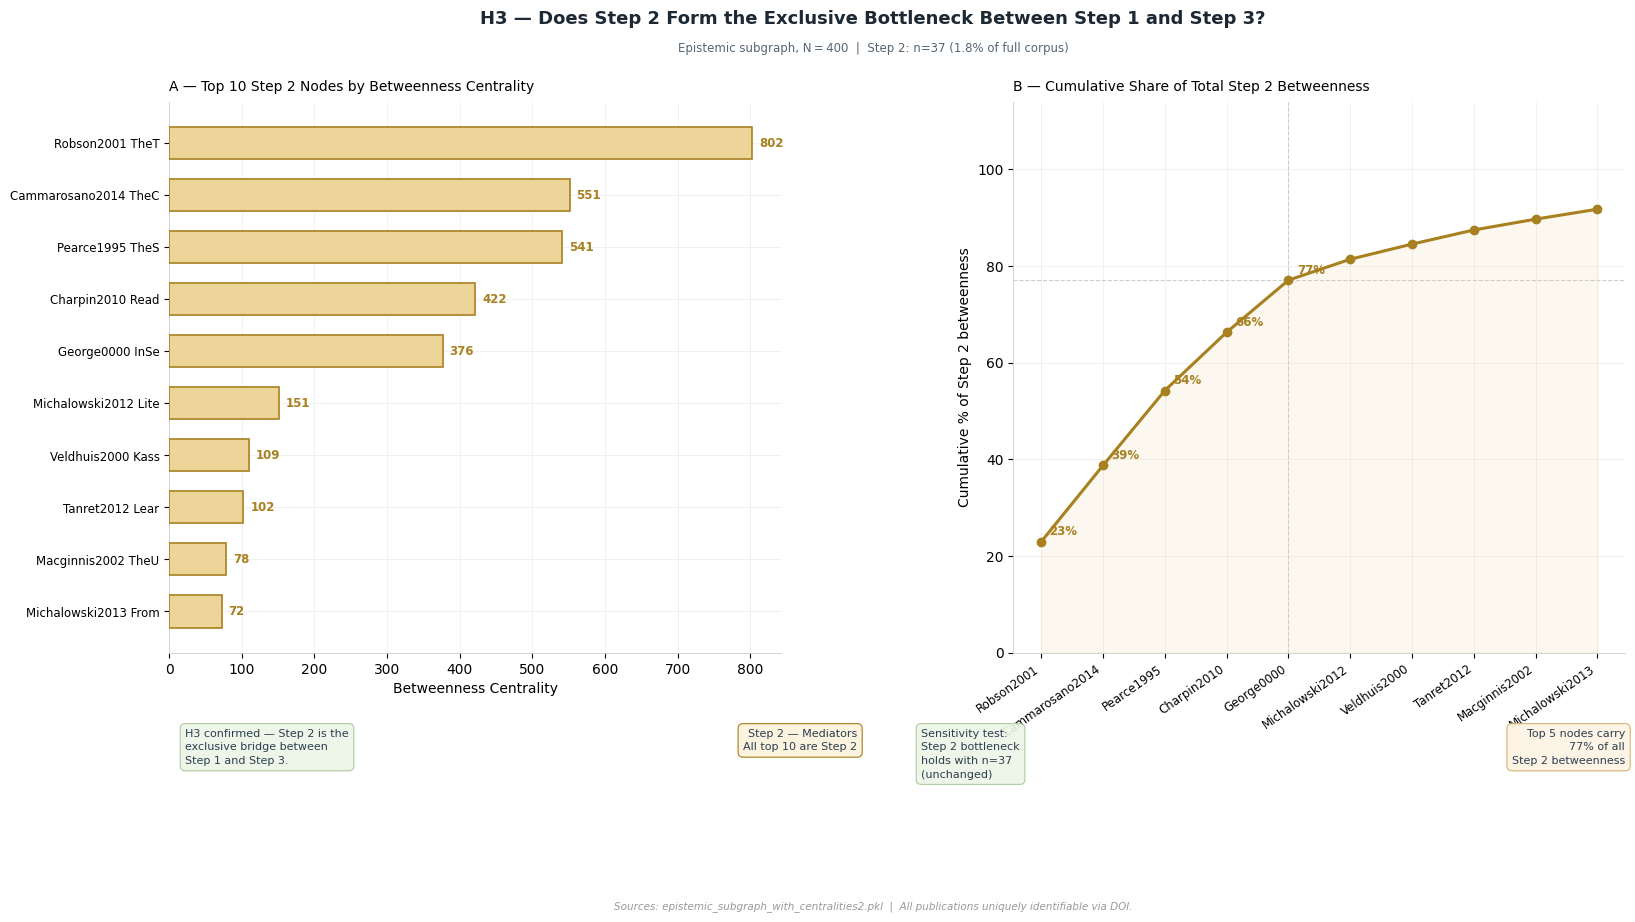

Saved → figure3_H3.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — H3  |  Final version for Google Colab
# Run after: Cell 1 (imports) → Cell 2 (upload) → Cell 3 (design system)
#            → Cell 4 (load pkl — provides g_cent, bet, indeg, idx2, names)
#
# Changes vs original:
#   1. White background (#FFFFFF)
#   2. Soft step colours (STEP_COLOR_SOFT[2] + STEP_EDGE_SOFT[2])
#   3. Panels C and D removed — only A and B remain
#   4. Annotation boxes placed in a dedicated row BELOW the charts:
#        2 boxes under Panel A  |  2 boxes under Panel B
#        All at the same vertical level → symmetric, no overlap with graphs
# ════════════════════════════════════════════════════════════════════════════

def add_footer(fig, text=None):
    fig.text(0.5, 0.030,
             text or ('Sources: epistemic_subgraph_with_centralities2.pkl  |  '
                      'All publications uniquely identifiable via DOI.'),
             ha='center', fontsize=FONT_TINY, color='#999999', fontstyle='italic')

def show_and_save(fig, filename):
    fig.savefig(filename, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f'Saved \u2192 {filename}')

apply_theme()

BG_WHITE         = '#FFFFFF'
STEP_COLOR_SOFT  = {1:'#EDADA0', 2:'#EDD498', 3:'#A4BED8', 4:'#C4B8DC', 5:'#D2CEC8'}
STEP_EDGE_SOFT   = {1:'#B05040', 2:'#A88020', 3:'#3060A0', 4:'#6050A0', 5:'#807870'}
STEP_COLOR_LIGHT_2 = '#FBF3DC'

# ── Compute top-10 Step 2 nodes ───────────────────────────────────────────
# idx2, bet, indeg, names come from Cell 4
s2_data    = [(names[i], bet[i], indeg[i]) for i in idx2]
top10_raw  = sorted(s2_data, key=lambda x: x[1], reverse=True)[:10]
labels_t10 = [r[0].split('_')[0]+' '+r[0].split('_')[1][:4]
              if '_' in r[0] else r[0][:14] for r in top10_raw]
bets_t10   = [r[1] for r in top10_raw]
total_bet2 = bet[idx2].sum()
cumvals    = list(np.cumsum(bets_t10) / total_bet2 * 100)

# ── Figure ────────────────────────────────────────────────────────────────
# Vertical zones (figure fraction from bottom):
#   0.030 – 0.060  footer
#   0.070 – 0.260  annotation row  <- 4 boxes here
#   0.300 – 0.880  chart axes
#   0.900 – 1.000  titles
fig = plt.figure(figsize=(16, 9.5))
fig.patch.set_facecolor(BG_WHITE)

gs = gridspec.GridSpec(1, 2, figure=fig,
                       left=0.06, right=0.97,
                       top=0.88, bottom=0.30,
                       wspace=0.38)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])

# ── Titles ────────────────────────────────────────────────────────────────
fig.text(0.5, 0.962,
         'H3 \u2014 Does Step 2 Form the Exclusive Bottleneck Between Step 1 and Step 3?',
         ha='center', fontsize=FONT_TITLE, fontweight='bold', color='#1C2833')
fig.text(0.5, 0.932,
         f'Epistemic subgraph, N\u2009=\u2009400  |  '
         f'Step 2: n={len(idx2)} (1.8% of full corpus)',
         ha='center', fontsize=FONT_SMALL, color=ACCENT_NEUTRAL)

# ══════════════════════════════════════════════════════════════════════════
# PANEL A — horizontal bar
# ══════════════════════════════════════════════════════════════════════════
ax_a.set_facecolor(BG_WHITE)
ax_a.set_title('A \u2014 Top 10 Step 2 Nodes by Betweenness Centrality',
               fontsize=FONT_SUBTITLE, loc='left', pad=8)

ax_a.barh(range(10), bets_t10[::-1],
          color=STEP_COLOR_SOFT[2], edgecolor=STEP_EDGE_SOFT[2],
          height=0.62, linewidth=1.2, zorder=3)
ax_a.set_yticks(range(10))
ax_a.set_yticklabels(labels_t10[::-1], fontsize=FONT_SMALL)
ax_a.set_xlabel('Betweenness Centrality', fontsize=FONT_BODY)
ax_a.xaxis.grid(True, color=GRID_COLOR, linewidth=0.5, zorder=0)
ax_a.set_axisbelow(True)
ax_a.set_facecolor(BG_WHITE)

for i, val in enumerate(bets_t10[::-1]):
    ax_a.text(val + max(bets_t10)*0.012, i, f'{val:.0f}',
              va='center', fontsize=FONT_SMALL,
              fontweight='bold', color=STEP_EDGE_SOFT[2])

# ══════════════════════════════════════════════════════════════════════════
# PANEL B — cumulative line
# ══════════════════════════════════════════════════════════════════════════
ax_b.set_facecolor(BG_WHITE)
ax_b.set_title('B \u2014 Cumulative Share of Total Step 2 Betweenness',
               fontsize=FONT_SUBTITLE, loc='left', pad=8)

xs = range(1, 11)
ax_b.plot(xs, cumvals, color=STEP_EDGE_SOFT[2], marker='o',
          linewidth=2.2, markersize=6, zorder=4)
ax_b.fill_between(xs, cumvals, alpha=0.14, color=STEP_COLOR_SOFT[2], zorder=3)

cross = next((i+1 for i,v in enumerate(cumvals) if v >= 75), None)
if cross:
    ax_b.axhline(cumvals[cross-1], color=SPINE_COLOR,
                 linewidth=0.8, linestyle='--', zorder=2)
    ax_b.axvline(cross, color=SPINE_COLOR,
                 linewidth=0.8, linestyle='--', zorder=2)

ax_b.set_xticks(range(1, 11))
ax_b.set_xticklabels([l.split()[0] for l in labels_t10],
                     rotation=35, ha='right', fontsize=FONT_SMALL)
ax_b.set_ylabel('Cumulative % of Step 2 betweenness', fontsize=FONT_BODY)
ax_b.set_ylim(0, 114)
ax_b.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, zorder=0)
ax_b.set_axisbelow(True)
ax_b.set_facecolor(BG_WHITE)

for x, y in zip(range(1, 6), cumvals[:5]):
    ax_b.annotate(f'{y:.0f}%', (x, y), textcoords='offset points', xytext=(6, 5),
                  fontsize=FONT_SMALL, color=STEP_EDGE_SOFT[2], fontweight='bold')

# ══════════════════════════════════════════════════════════════════════════
# ANNOTATION ROW — 4 boxes via fig.text(), same y, symmetric pairs
#
# Why fig.text() instead of ax.text()?
# ax.text() clips to axes boundaries → boxes at negative y get cut off.
# fig.text() uses figure-level coordinates → always fully visible.
#
# BOX_Y = top edge of all boxes in figure fraction (0 = bottom, 1 = top)
# ══════════════════════════════════════════════════════════════════════════
BOX_Y = 0.22

# Panel A left — "H3 confirmed" (green)
fig.text(0.07, BOX_Y,
         'H3 confirmed \u2014 Step 2 is the\nexclusive bridge between\nStep 1 and Step 3.',
         ha='left', va='top', fontsize=FONT_SMALL-0.5,
         color='#2C3E50', linespacing=1.45,
         bbox=dict(boxstyle='round,pad=0.45',
                   facecolor='#EDF5E8', edgecolor='#A8C99A',
                   linewidth=0.8, alpha=0.92))

# Panel A right — "All top 10 Step 2" (amber)
fig.text(0.49, BOX_Y,
         'Step 2 \u2014 Mediators\nAll top 10 are Step 2',
         ha='right', va='top', fontsize=FONT_SMALL-0.5,
         color='#2C3E50', linespacing=1.45,
         bbox=dict(boxstyle='round,pad=0.45',
                   facecolor=STEP_COLOR_LIGHT_2, edgecolor=STEP_EDGE_SOFT[2],
                   linewidth=0.9, alpha=0.92))

# Panel B left — "Sensitivity test" (green)
fig.text(0.53, BOX_Y,
         'Sensitivity test:\nStep 2 bottleneck\nholds with n=37\n(unchanged)',
         ha='left', va='top', fontsize=FONT_SMALL-0.5,
         color='#2C3E50', linespacing=1.45,
         bbox=dict(boxstyle='round,pad=0.45',
                   facecolor='#EDF5E8', edgecolor='#A8C99A',
                   linewidth=0.8, alpha=0.92))

# Panel B right — "Top 5 carry 77%" (amber)
fig.text(0.97, BOX_Y,
         f'Top 5 nodes carry\n{cumvals[4]:.0f}% of all\nStep 2 betweenness',
         ha='right', va='top', fontsize=FONT_SMALL-0.5,
         color='#2C3E50', linespacing=1.45,
         bbox=dict(boxstyle='round,pad=0.45',
                   facecolor='#FDF4E3', edgecolor='#D4AD6A',
                   linewidth=0.8, alpha=0.92))

# ── Footer ────────────────────────────────────────────────────────────────
add_footer(fig)
show_and_save(fig, 'figure3_H3.png')

####**Hypothesis 4**

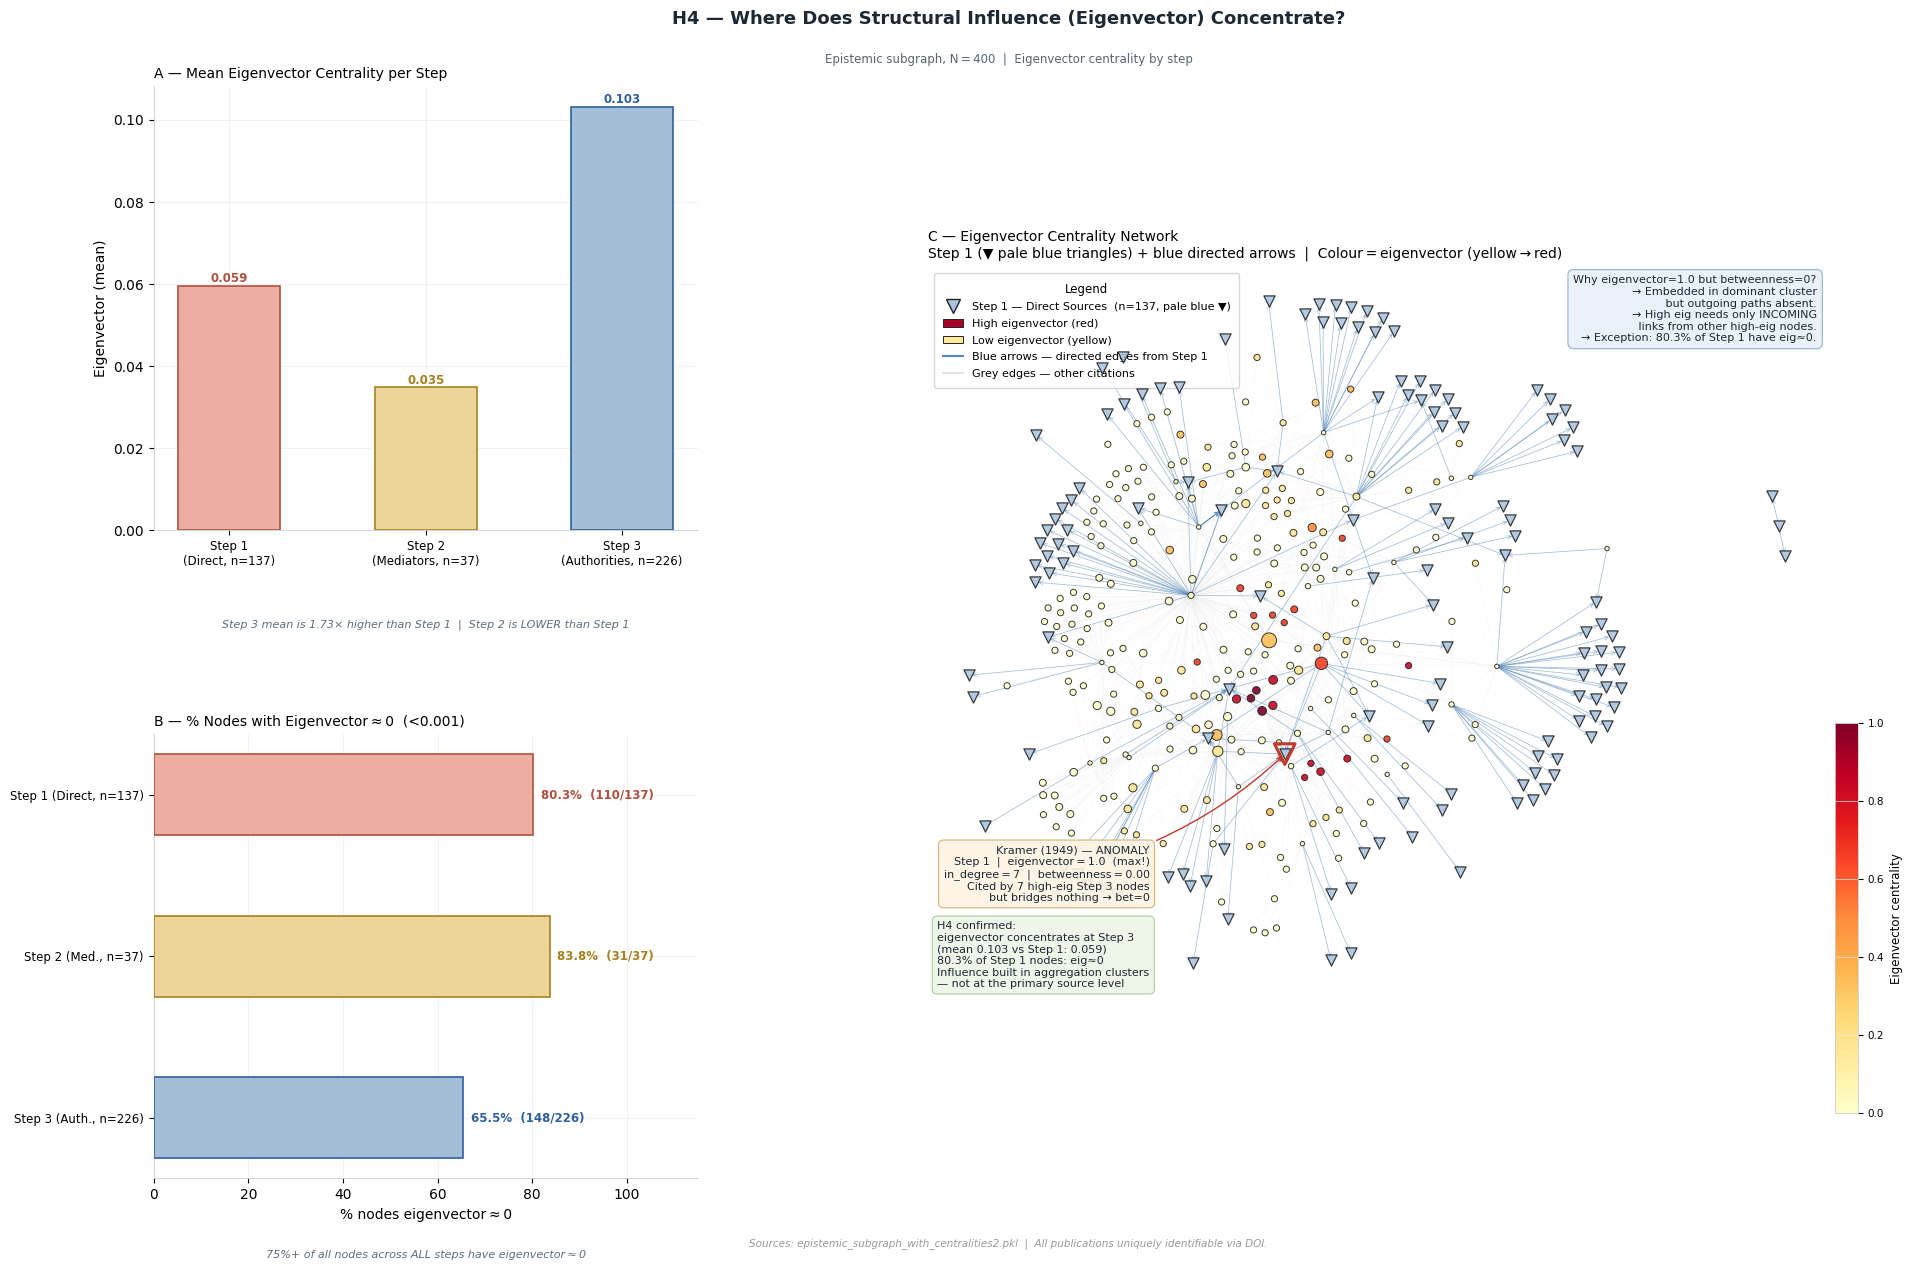

Saved → figure4_H4.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — H4  |  Final version for Google Colab
# Run after: Cell 1 → Cell 2 → Cell 3 (design system)
#            → Cell 4 (g_cent, coords, idx1/2/3, bet, indeg, eig, steps, names)
#
# Fixes in this version:
#   Fix 1 — ALL nodes (non-Step1) get black border: edgecolors='#222222'
#            Makes every node visible against white background regardless of
#            YlOrRd fill colour; also applied to Step1 blue triangles
#   Fix 2 — "H4 confirmed" badge anchored to absolute bottom-left corner:
#            y=0.01, va='bottom' — cannot overlap Kramer annotation
#            which floats in the middle of the graph
# ════════════════════════════════════════════════════════════════════════════

def add_footer(fig, text=None):
    fig.text(0.5, 0.018,
             text or ('Sources: epistemic_subgraph_with_centralities2.pkl  |  '
                      'All publications uniquely identifiable via DOI.'),
             ha='center', fontsize=FONT_TINY, color='#999999', fontstyle='italic')

def show_and_save(fig, filename):
    fig.savefig(filename, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f'Saved \u2192 {filename}')

apply_theme()

BG_WHITE = '#FFFFFF'
STEP_COLOR_SOFT = {1:'#EDADA0', 2:'#EDD498', 3:'#A4BED8'}
STEP_EDGE_SOFT  = {1:'#B05040', 2:'#A88020', 3:'#3060A0'}

S1_NODE_COLOR = '#A8C4E0'   # pale blue triangles
S1_EDGE_COLOR = '#5588BB'   # blue directed arrows

EIG_CMAP = mpl.colormaps['YlOrRd']  # light yellow → saturated red

# ── Normalise eigenvector ─────────────────────────────────────────────────
p99      = np.percentile(eig, 99)
clipped  = np.clip(eig, 0, p99)
norm_eig = (clipped - clipped.min()) / (clipped.max() - clipped.min() + 1e-12)

ns3       = [len(idx1), len(idx2), len(idx3)]
means_eig = [eig[idx1].mean(), eig[idx2].mean(), eig[idx3].mean()]
pct_z_eig = [100*(eig[idx]<0.001).mean() for idx in [idx1,idx2,idx3]]

node_colors = [EIG_CMAP(norm_eig[i]) for i in range(g_cent.vcount())]

# ── Figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(19, 13))
fig.patch.set_facecolor(BG_WHITE)

gs = gridspec.GridSpec(2, 2, figure=fig,
                       left=0.05, right=0.93,
                       top=0.91, bottom=0.07,
                       hspace=0.46, wspace=0.32,
                       width_ratios=[1, 1.65])
ax_a   = fig.add_subplot(gs[0, 0])
ax_b   = fig.add_subplot(gs[1, 0])
ax_net = fig.add_subplot(gs[:, 1])

fig.text(0.5, 0.958,
         'H4 \u2014 Where Does Structural Influence (Eigenvector) Concentrate?',
         ha='center', fontsize=FONT_TITLE, fontweight='bold', color='#1C2833')
fig.text(0.5, 0.928,
         'Epistemic subgraph, N\u2009=\u2009400  |  Eigenvector centrality by step',
         ha='center', fontsize=FONT_SMALL, color=ACCENT_NEUTRAL)

# ══ Panel A ════════════════════════════════════════════════════════════════
ax_a.set_facecolor(BG_WHITE)
ax_a.set_title('A \u2014 Mean Eigenvector Centrality per Step',
               fontsize=FONT_SUBTITLE, loc='left', pad=6)
s_c = [STEP_COLOR_SOFT[1], STEP_COLOR_SOFT[2], STEP_COLOR_SOFT[3]]
s_e = [STEP_EDGE_SOFT[1],  STEP_EDGE_SOFT[2],  STEP_EDGE_SOFT[3]]
lbl = [f'Step {s}\n({["Direct","Mediators","Authorities"][s-1]}, n={ns3[s-1]})'
       for s in [1, 2, 3]]
bars = ax_a.bar([0,1,2], means_eig, width=0.52,
                color=s_c, edgecolor=s_e, linewidth=1.2, zorder=3)
ax_a.set_xticks([0,1,2]); ax_a.set_xticklabels(lbl, fontsize=FONT_SMALL)
ax_a.set_ylabel('Eigenvector (mean)', fontsize=FONT_BODY)
ax_a.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, zorder=0)
ax_a.set_axisbelow(True); ax_a.set_facecolor(BG_WHITE)
for bar, val, ec in zip(bars, means_eig, s_e):
    ax_a.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
              f'{val:.3f}', ha='center', fontsize=FONT_SMALL,
              fontweight='bold', color=ec)
ax_a.text(0.5, -0.22,
          f'Step 3 mean is {means_eig[2]/means_eig[0]:.2f}\u00d7 higher than Step 1  |  '
          'Step 2 is LOWER than Step 1',
          transform=ax_a.transAxes, ha='center',
          fontsize=FONT_SMALL-0.5, color='#5D6D7E', style='italic')

# ══ Panel B ════════════════════════════════════════════════════════════════
ax_b.set_facecolor(BG_WHITE)
ax_b.set_title('B \u2014 % Nodes with Eigenvector\u2009\u2248\u20090  (<0.001)',
               fontsize=FONT_SUBTITLE, loc='left', pad=6)
ax_b.barh([0,1,2], pct_z_eig[::-1],
          color=s_c[::-1], edgecolor=s_e[::-1],
          height=0.50, linewidth=1.2, zorder=3)
ax_b.set_yticks([0,1,2])
ax_b.set_yticklabels(
    [f'Step {s} ({["Direct","Med.","Auth."][s-1]}, n={ns3[s-1]})' for s in [3,2,1]],
    fontsize=FONT_SMALL)
ax_b.set_xlabel('% nodes eigenvector\u2009\u2248\u20090', fontsize=FONT_BODY)
ax_b.set_xlim(0, 115)
ax_b.xaxis.grid(True, color=GRID_COLOR, linewidth=0.5, zorder=0)
ax_b.set_axisbelow(True); ax_b.set_facecolor(BG_WHITE)
c_str = [f'{int(pct_z_eig[2]*ns3[2]/100)}/{ns3[2]}',
         f'{int(pct_z_eig[1]*ns3[1]/100)}/{ns3[1]}',
         f'{int(pct_z_eig[0]*ns3[0]/100)}/{ns3[0]}']
for patch, val, cnt, ec in zip(ax_b.patches, pct_z_eig[::-1], c_str, s_e[::-1]):
    ax_b.text(val+1.5, patch.get_y()+patch.get_height()/2,
              f'{val:.1f}%  ({cnt})', va='center',
              fontsize=FONT_SMALL, fontweight='bold', color=ec)
ax_b.text(0.5, -0.18,
          '75%+ of all nodes across ALL steps have eigenvector\u2009\u2248\u20090',
          transform=ax_b.transAxes, ha='center',
          fontsize=FONT_SMALL-0.5, color='#5D6D7E', style='italic')

# ══ Panel C: Network ═══════════════════════════════════════════════════════
ax_net.set_facecolor(BG_WHITE)
ax_net.set_aspect('equal'); ax_net.axis('off')
ax_net.set_title(
    'C \u2014 Eigenvector Centrality Network\n'
    'Step 1 (\u25bc pale blue triangles) + blue directed arrows  |  '
    'Colour\u2009=\u2009eigenvector (yellow\u2009\u2192\u2009red)',
    fontsize=FONT_SUBTITLE, loc='left', pad=8)

# ── Edges ─────────────────────────────────────────────────────────────────
for e in g_cent.es:
    s, t = e.source, e.target
    if steps[s] == 1 or steps[t] == 1:
        ax_net.annotate('',
            xy=(coords[t,0], coords[t,1]),
            xytext=(coords[s,0], coords[s,1]),
            arrowprops=dict(arrowstyle='->', color=S1_EDGE_COLOR,
                            lw=0.55, alpha=0.55, mutation_scale=7),
            zorder=2)
    else:
        ax_net.plot([coords[s,0],coords[t,0]], [coords[s,1],coords[t,1]],
                    color='#DDDDDD', lw=0.22, alpha=0.35, zorder=1)

# ── Nodes — Fix 1: BLACK BORDER on every node ─────────────────────────────
# edgecolors='#222222' makes every node clearly visible against white BG
# regardless of how light or dark the YlOrRd fill is

non_s1 = [i for i in range(g_cent.vcount()) if steps[i] != 1]
ax_net.scatter(
    coords[non_s1, 0], coords[non_s1, 1],
    s=[max(10 + indeg[i]*5, 8) for i in non_s1],
    c=[node_colors[i] for i in non_s1],
    alpha=0.90,
    edgecolors='#222222',    # ← black border on ALL gradient nodes
    linewidths=0.7,
    zorder=4)

# Step 1 — pale blue triangles, also black border
ax_net.scatter(
    coords[idx1, 0], coords[idx1, 1],
    s=65,
    c=S1_NODE_COLOR,
    alpha=0.88,
    edgecolors='#222222',    # ← black border on Step1 triangles too
    linewidths=0.9,
    marker='v',
    zorder=6)

# ── Kramer anomaly annotation ─────────────────────────────────────────────
kramer_idx = next((i for i,n in enumerate(names) if 'Kramer1949' in n), None)
if kramer_idx is not None:
    kx, ky = coords[kramer_idx]
    ax_net.scatter(kx, ky, s=220, c='none',
                   edgecolors='#C0392B', linewidths=2.2,
                   marker='v', zorder=9)
    ax_net.annotate(
        'Kramer (1949) \u2014 ANOMALY\n'
        'Step 1  |  eigenvector\u2009=\u20091.0  (max!)\n'
        'in_degree\u2009=\u20097  |  betweenness\u2009=\u20090.00\n'
        'Cited by 7 high-eig Step 3 nodes\n'
        'but bridges nothing \u2192 bet=0',
        xy=(kx, ky),
        xytext=(kx - 5.0, ky - 5.5),   # BELOW and LEFT of node
        fontsize=FONT_SMALL-0.5, color='#1C2833',
        va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.45', facecolor=BG_BOX_AMBER,
                  edgecolor=EDGE_AMBER, linewidth=0.8, alpha=0.93),
        arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.0,
                        connectionstyle='arc3,rad=0.15'),
        zorder=10)

# ── "Why high eig but bet=0" — top right ──────────────────────────────────
ax_net.text(0.99, 0.99,
            'Why eigenvector=1.0 but betweenness=0?\n'
            '\u2192 Embedded in dominant cluster\n'
            '   but outgoing paths absent.\n'
            '\u2192 High eig needs only INCOMING\n'
            '   links from other high-eig nodes.\n'
            '\u2192 Exception: 80.3% of Step 1 have eig\u22480.',
            transform=ax_net.transAxes,
            fontsize=FONT_SMALL-0.5, color='#1C2833',
            va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.50', facecolor=BG_BOX_BLUE,
                      edgecolor=EDGE_BLUE, linewidth=0.8, alpha=0.93),
            zorder=10)

# ── Fix 2: H4 confirmed — ABSOLUTE BOTTOM-LEFT, cannot overlap Kramer ─────
# va='bottom' + y=0.01 anchors the BOTTOM EDGE of the box to y=1%
# Kramer annotation floats mid-graph in data coords → always above this
ax_net.text(0.01, 0.01,
            'H4 confirmed:\neigenvector concentrates at Step 3\n'
            f'(mean {means_eig[2]:.3f} vs Step 1: {means_eig[0]:.3f})\n'
            '80.3% of Step 1 nodes: eig\u22480\n'
            'Influence built in aggregation clusters\n'
            '\u2014 not at the primary source level',
            transform=ax_net.transAxes,
            fontsize=FONT_SMALL-0.5, color='#1C2833',
            va='bottom', ha='left',
            bbox=dict(boxstyle='round,pad=0.45', facecolor=BG_BOX_GREEN,
                      edgecolor=EDGE_GREEN, linewidth=0.8, alpha=0.93),
            zorder=10)

# ── Colorbar ──────────────────────────────────────────────────────────────
from matplotlib.cm import ScalarMappable
sm = ScalarMappable(cmap='YlOrRd', norm=mcolors.Normalize(0, eig.max()))
sm.set_array([])
cbar_ax = fig.add_axes([0.935, 0.12, 0.012, 0.30])
cbar = plt.colorbar(sm, cax=cbar_ax)
cbar.set_label('Eigenvector centrality', fontsize=FONT_SMALL)
cbar.ax.tick_params(labelsize=FONT_SMALL-1)

# ── Legend ────────────────────────────────────────────────────────────────
ax_net.legend(handles=[
    Line2D([0],[0], marker='v', color='w',
           markerfacecolor=S1_NODE_COLOR, markeredgecolor='#222222',
           markersize=10, linewidth=0,
           label=f'Step 1 \u2014 Direct Sources  (n={len(idx1)}, pale blue \u25bc)'),
    mpatches.Patch(fc=EIG_CMAP(0.92), ec='#222222', lw=0.7,
                   label='High eigenvector (red)'),
    mpatches.Patch(fc=EIG_CMAP(0.15), ec='#222222', lw=0.7,
                   label='Low eigenvector (yellow)'),
    Line2D([0],[0], color=S1_EDGE_COLOR, lw=1.5,
           label='Blue arrows \u2014 directed edges from Step 1'),
    Line2D([0],[0], color='#DDDDDD', lw=1.2,
           label='Grey edges \u2014 other citations'),
], loc='upper left', fontsize=FONT_SMALL-0.5, frameon=True,
   facecolor=BG_WHITE, edgecolor=SPINE_COLOR,
   title='Legend', title_fontsize=FONT_SMALL,
   borderpad=0.8, handlelength=1.8, labelspacing=0.6)

add_footer(fig)
show_and_save(fig, 'figure4_H4.png')

####**Hypothesis 5**

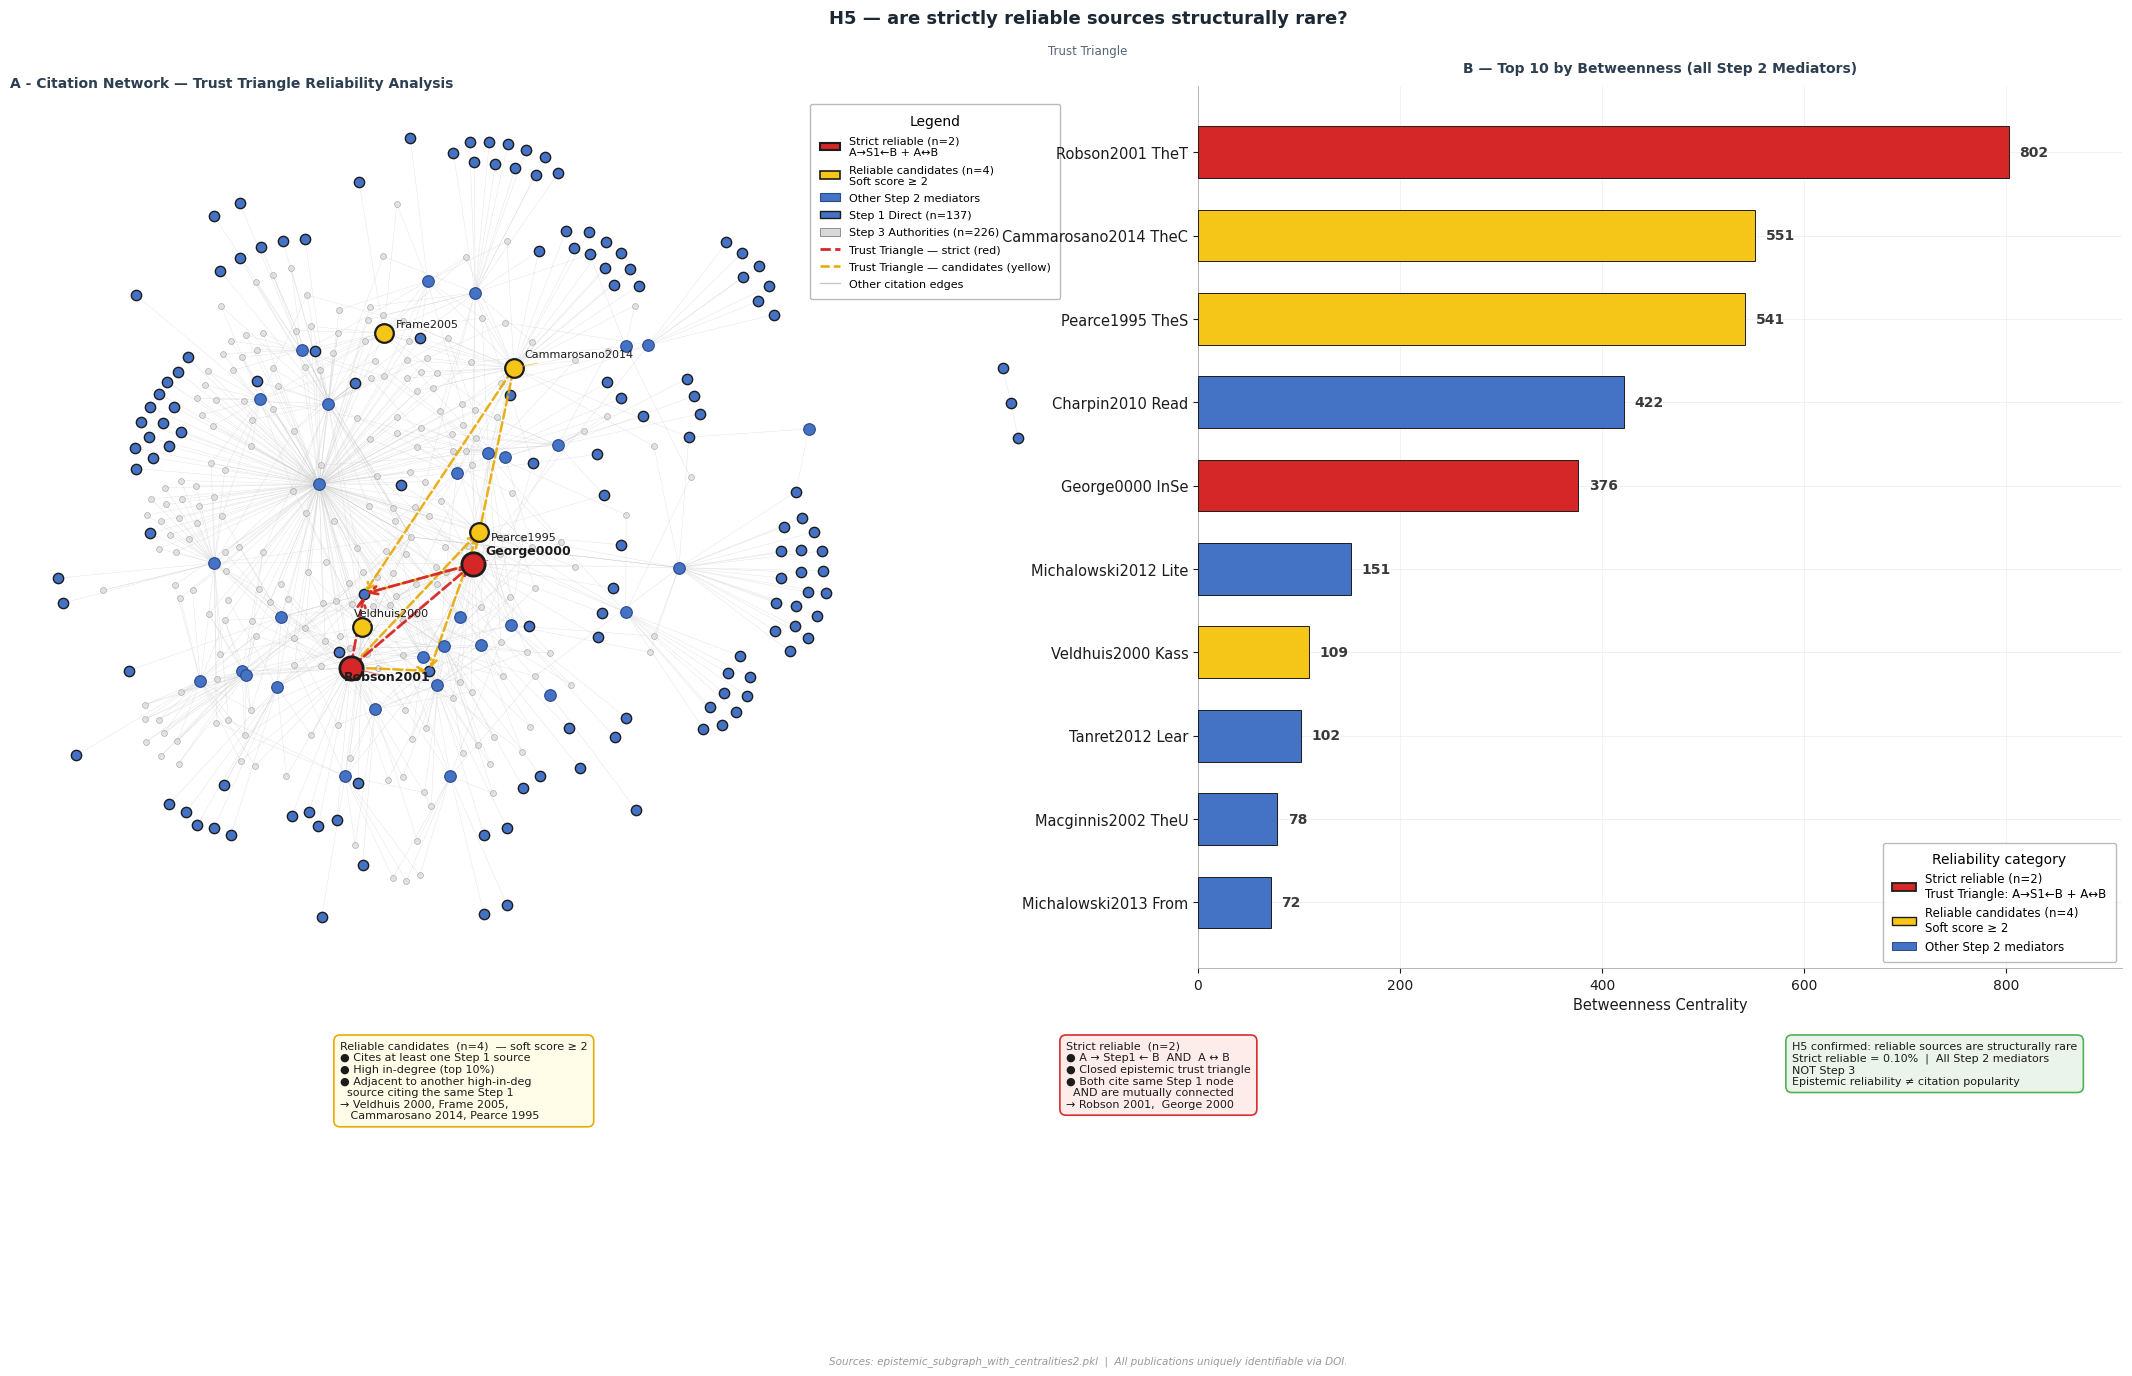

Saved → figure5_H5.png


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Name: Cell 9 - Figure 5: H5 Trust Triangle Network + Betweenness Bar
Description: Added yellow dashed triangle edges for reliable candidates (soft4),
             separate from red dashed triangle edges for strict reliable sources.
             Both triangle sets drawn independently with matching node colours.
Author: student
Date: 2026-05-09
Version: 2.1
"""

# CELL 9 — Figure 5: H5 — Trust Triangle network + betweenness bar (v2.1)

apply_theme()

# ── COLOUR PALETTE ────────────────────────────────────────────────────────────
REL_STRICT_COLOR  = '#D62728'
REL_STRICT_EDGE   = '#1C1C1C'
REL_SOFT_COLOR    = '#F5C518'
REL_SOFT_EDGE     = '#1C1C1C'
REL_OTHER_COLOR   = '#4472C4'
REL_OTHER_EDGE    = '#2A4A8A'
STEP1_COLOR       = '#4472C4'
STEP1_EDGE        = '#1C1C1C'
STEP3_COLOR       = '#D8D8D8'
STEP3_EDGE        = '#909090'
EDGE_GRAY         = '#C8C8C8'
EDGE_TRIANGLE_RED    = '#D62728'   # strict reliable triangle — red dashed
EDGE_TRIANGLE_YELLOW = '#E8A800'   # candidate triangle — yellow/amber dashed
BG_FIGURE_NEW     = '#FFFFFF'
# ─────────────────────────────────────────────────────────────────────────────

# ── COMPUTE CANDIDATE TRIANGLE EDGES (soft4) ──────────────────────────────────
# Mirrors the logic from 10.2.Top10ReliableSources.py but only for soft4 nodes.
# For each candidate in soft4 (that is NOT already a strict reliable):
#   find a Step-1 neighbour s  AND  a high-in-degree neighbour b
#   that also cites s.  Mark edges (candidate→s), (candidate→b), (b→s).

soft4_triangle_edge_ids = set()   # yellow dashed edges

for a_id in soft4:
    if a_id in reliable_strict:
        continue   # strict sources already handled by red triangles

    # Step-1 nodes reachable from this candidate
    a_step1 = set(g_comm.successors(a_id)) & {
        v.index for v in g_comm.vs if v['step_distance'] == 1
    }
    if not a_step1:
        continue

    # High in-degree set (reuse the same threshold as the analysis)
    indeg_arr = [v.indegree() for v in g_comm.vs]   # or use pre-computed `indeg`
    import numpy as np
    indeg_thr = np.percentile(indeg_arr, 90)
    high_indeg = {v.index for v in g_comm.vs if g_comm.indegree(v.index) >= indeg_thr}

    # Find partner b
    for b_id in high_indeg:
        if b_id == a_id:
            continue
        b_step1 = set(g_comm.successors(b_id)) & a_step1
        if not b_step1:
            continue
        if g_comm.are_connected(a_id, b_id) or g_comm.are_connected(b_id, a_id):
            s = next(iter(b_step1))
            # collect the three triangle edges
            for x, y in [(a_id, b_id), (a_id, s), (b_id, s)]:
                eid = g_comm.get_eid(x, y, directed=False, error=False)
                if eid != -1:
                    soft4_triangle_edge_ids.add(eid)
            break   # one triangle per candidate

# Combined set of ALL triangle edge ids (used to skip in regular-edge loop)
all_triangle_ids = triangle_edge_ids | soft4_triangle_edge_ids

# ── Top-10 step-2 by betweenness ──────────────────────────────────────────────
s2_bar    = [(v.index, v['name'], bet[v.index])
             for v in g_comm.vs if v['step_distance'] == 2]
top10_bar = sorted(s2_bar, key=lambda x: x[2], reverse=True)[:10]

def bar_col(vid):
    if vid in reliable_strict: return REL_STRICT_COLOR
    if vid in soft4:           return REL_SOFT_COLOR
    return REL_OTHER_COLOR

def node_style_h5(vid):
    if vid in reliable_strict:
        return REL_STRICT_COLOR, REL_STRICT_EDGE, 280, 2.0, 9
    if vid in soft4:
        return REL_SOFT_COLOR,   REL_SOFT_EDGE,   180, 1.6, 8
    step = g_comm.vs[vid]['step_distance']
    if step == 1:
        return STEP1_COLOR, STEP1_EDGE, 55,  1.0, 4
    if step == 2:
        return REL_OTHER_COLOR, REL_OTHER_EDGE, 70, 0.8, 5
    return STEP3_COLOR, STEP3_EDGE, 18, 0.5, 2

# ── FIGURE LAYOUT ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor(BG_FIGURE_NEW)

ax_net  = fig.add_axes([0.01, 0.30, 0.48, 0.63])
ax_bar  = fig.add_axes([0.55, 0.30, 0.42, 0.63])
ax_ann1 = fig.add_axes([0.01, 0.02, 0.30, 0.24])
ax_ann2 = fig.add_axes([0.34, 0.02, 0.30, 0.24])
ax_ann3 = fig.add_axes([0.67, 0.02, 0.30, 0.24])
for ax in [ax_ann1, ax_ann2, ax_ann3]:
    ax.axis('off')
    ax.set_facecolor(BG_FIGURE_NEW)

# ── TITLES ────────────────────────────────────────────────────────────────────
fig.text(0.5, 0.975,
         'H5 — are strictly reliable sources structurally rare?',
         ha='center', fontsize=FONT_TITLE, fontweight='bold', color='#1C2833')
fig.text(0.5, 0.953, 'Trust Triangle',
         ha='center', fontsize=FONT_SMALL, color=ACCENT_NEUTRAL)

# ── NETWORK PANEL ─────────────────────────────────────────────────────────────
ax_net.set_facecolor(BG_FIGURE_NEW)
ax_net.set_aspect('equal')
ax_net.axis('off')
ax_net.set_title('A - Citation Network — Trust Triangle Reliability Analysis',
                 fontsize=FONT_SUBTITLE, loc='left',fontweight='bold', pad=8, color='#2C3E50')

# 1. Regular edges (skip ALL triangle edges)
for e in g_comm.es:
    if e.index in all_triangle_ids:
        continue
    s, t = e.source, e.target
    ax_net.plot(
        [coords[s, 0], coords[t, 0]],
        [coords[s, 1], coords[t, 1]],
        color=EDGE_GRAY, lw=0.30, alpha=0.55, zorder=1
    )

# 2. RED dashed arrows — strict reliable triangles
for e in g_comm.es:
    if e.index not in triangle_edge_ids:
        continue
    s, t = e.source, e.target
    ax_net.annotate(
        '', xy=(coords[t, 0], coords[t, 1]),
        xytext=(coords[s, 0], coords[s, 1]),
        arrowprops=dict(
            arrowstyle='->',
            color=EDGE_TRIANGLE_RED,
            lw=2.0,
            linestyle='dashed',
            mutation_scale=14,
            alpha=0.95
        ),
        zorder=6
    )

# 3. YELLOW dashed arrows — candidate triangles (soft4)
for e in g_comm.es:
    if e.index not in soft4_triangle_edge_ids:
        continue
    s, t = e.source, e.target
    ax_net.annotate(
        '', xy=(coords[t, 0], coords[t, 1]),
        xytext=(coords[s, 0], coords[s, 1]),
        arrowprops=dict(
            arrowstyle='->',
            color=EDGE_TRIANGLE_YELLOW,
            lw=1.8,
            linestyle='dashed',
            mutation_scale=12,
            alpha=0.90
        ),
        zorder=5
    )

# 4. Nodes (layered by zorder)
for zo_t in [2, 4, 5, 8, 9]:
    for v in g_comm.vs:
        vid = v.index
        col, ec_n, sz, lw_n, zo = node_style_h5(vid)
        if zo != zo_t:
            continue
        ax_net.scatter(
            coords[vid, 0], coords[vid, 1],
            s=sz, c=col, zorder=zo,
            edgecolors=ec_n, linewidths=lw_n,
            alpha=1.0 if zo >= 4 else 0.70
        )

# 5. Labels for key nodes
label_offsets = {
    'George0000_InSearchOf':       ( 0.40,  0.32),
    'Robson2001_TheTabletH':       (-0.20, -0.40),
    'Veldhuis2000_KassiteExe':     (-0.25,  0.32),
    'Frame2005_TheRoyalLi':        ( 0.38,  0.20),
    'Cammarosano2014_TheCuneifo':  ( 0.32,  0.32),
    'Pearce1995_TheScribes':       ( 0.38, -0.26),
}
for v in g_comm.vs:
    name = v['name']
    if name not in label_offsets:
        continue
    dx, dy = label_offsets[name]
    col, *_ = node_style_h5(v.index)
    x, y = coords[v.index]
    is_strict = v.index in reliable_strict
    ax_net.annotate(
        name.split('_')[0],
        xy=(x, y), xytext=(x + dx, y + dy),
        fontsize=9.0 if is_strict else 8.0,
        fontweight='bold' if is_strict else 'normal',
        color='#1C1C1C',
        arrowprops=dict(arrowstyle='-', color=col, lw=0.6, alpha=0.75),
        zorder=10
    )

# 6. Legend — network panel (top-right)
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

ax_net.legend(
    handles=[
        mpatches.Patch(fc=REL_STRICT_COLOR, ec=REL_STRICT_EDGE, lw=1.5,
            label=f'Strict reliable (n={len(reliable_strict)})\nA→S1←B + A↔B'),
        mpatches.Patch(fc=REL_SOFT_COLOR, ec=REL_SOFT_EDGE, lw=1.2,
            label=f'Reliable candidates (n={len(soft4)})\nSoft score ≥ 2'),
        mpatches.Patch(fc=REL_OTHER_COLOR, ec=REL_OTHER_EDGE, lw=0.8,
            label='Other Step 2 mediators'),
        mpatches.Patch(fc=STEP1_COLOR, ec=STEP1_EDGE, lw=1.0,
            label='Step 1 Direct (n=137)'),
        mpatches.Patch(fc=STEP3_COLOR, ec=STEP3_EDGE, lw=0.7,
            label='Step 3 Authorities (n=226)'),
        # Two separate triangle edge types
        Line2D([0], [0], color=EDGE_TRIANGLE_RED, lw=2.0, linestyle='dashed',
               label='Trust Triangle — strict (red)'),
        Line2D([0], [0], color=EDGE_TRIANGLE_YELLOW, lw=1.8, linestyle='dashed',
               label='Trust Triangle — candidates (yellow)'),
        Line2D([0], [0], color=EDGE_GRAY, lw=1.0,
               label='Other citation edges'),
    ],
    loc='upper right',
    fontsize=FONT_SMALL - 0.5,
    frameon=True,
    facecolor='#FFFFFF',
    edgecolor='#AAAAAA',
    title='Legend', title_fontsize=FONT_BODY,
    borderpad=0.9, handlelength=1.8, labelspacing=0.65
)

# ── ANNOTATION BOXES (below graph) ────────────────────────────────────────────
ax_ann2.text(
    0.5, 0.95,
    'Strict reliable  (n=2)\n'
    '● A → Step1 ← B  AND  A ↔ B\n'
    '● Closed epistemic trust triangle\n'
    '● Both cite same Step 1 node\n'
    '  AND are mutually connected\n'
    '→ Robson 2001,  George 2000',
    transform=ax_ann2.transAxes, fontsize=FONT_SMALL - 0.5,
    color='#1C1C1C', va='top', ha='left',
    bbox=dict(boxstyle='round,pad=0.55', facecolor='#FDECEA',
              edgecolor=REL_STRICT_COLOR, linewidth=1.2, alpha=0.97)
)
ax_ann1.text(
    0.5, 0.95,
    'Reliable candidates  (n=4)  — soft score ≥ 2\n'
    '● Cites at least one Step 1 source\n'
    '● High in-degree (top 10%)\n'
    '● Adjacent to another high-in-deg\n'
    '  source citing the same Step 1\n'
    '→ Veldhuis 2000, Frame 2005,\n'
    '   Cammarosano 2014, Pearce 1995',
    transform=ax_ann1.transAxes, fontsize=FONT_SMALL - 0.5,
    color='#1C1C1C', va='top', ha='left',
    bbox=dict(boxstyle='round,pad=0.55', facecolor='#FFFDE7',
              edgecolor=EDGE_TRIANGLE_YELLOW, linewidth=1.2, alpha=0.97)
)
ax_ann3.text(
    0.5, 0.95,
    'H5 confirmed: reliable sources are structurally rare\n'
    'Strict reliable = 0.10%  |  All Step 2 mediators\n'
    'NOT Step 3\n'
    'Epistemic reliability ≠ citation popularity',
    transform=ax_ann3.transAxes, fontsize=FONT_SMALL - 0.5,
    color='#1C1C1C', va='top', ha='left',
    bbox=dict(boxstyle='round,pad=0.55', facecolor='#EAF4EA',
              edgecolor='#4CAF50', linewidth=1.2, alpha=0.97)
)

# ── BAR CHART ─────────────────────────────────────────────────────────────────
ax_bar.set_facecolor(BG_FIGURE_NEW)
ax_bar.set_title(
    'B — Top 10 by Betweenness (all Step 2 Mediators)',
    fontsize=FONT_SUBTITLE, fontweight='bold', loc='center', pad=10, color='#2C3E50'
)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
ax_bar.spines['left'].set_color('#AAAAAA')
ax_bar.spines['bottom'].set_color('#AAAAAA')

labels_b, bets_b, colors_b = [], [], []
for vid, nm, bv in top10_bar:
    parts = nm.split('_')
    labels_b.append(parts[0] + ' ' + (parts[1][:4] if len(parts) > 1 else ''))
    bets_b.append(bv)
    colors_b.append(bar_col(vid))

ax_bar.barh(range(10), bets_b, color=colors_b,
            edgecolor='#1C1C1C', linewidth=0.7, height=0.62, zorder=3)
ax_bar.set_yticks(range(10))
ax_bar.set_yticklabels(labels_b, fontsize=FONT_BODY + 0.5, color='#1C1C1C')
ax_bar.set_xlabel('Betweenness Centrality', fontsize=FONT_BODY + 0.5, color='#1C1C1C')
ax_bar.tick_params(colors='#1C1C1C')
ax_bar.invert_yaxis()
ax_bar.set_xlim(0, max(bets_b) * 1.14)
ax_bar.xaxis.grid(True, color='#EEEEEE', linewidth=0.5, zorder=0)
ax_bar.set_axisbelow(True)

for i, val in enumerate(bets_b):
    ax_bar.text(val + max(bets_b) * 0.013, i, f'{val:.0f}',
                va='center', fontsize=FONT_BODY, fontweight='bold', color='#3A3A3A')

ax_bar.legend(
    handles=[
        mpatches.Patch(fc=REL_STRICT_COLOR, ec=REL_STRICT_EDGE, lw=1.3,
            label=f'Strict reliable (n={len(reliable_strict)})\nTrust Triangle: A→S1←B + A↔B'),
        mpatches.Patch(fc=REL_SOFT_COLOR, ec=REL_SOFT_EDGE, lw=1.0,
            label=f'Reliable candidates (n={len(soft4)})\nSoft score ≥ 2'),
        mpatches.Patch(fc=REL_OTHER_COLOR, ec=REL_OTHER_EDGE, lw=0.7,
            label='Other Step 2 mediators'),
    ],
    loc='lower right',
    fontsize=FONT_SMALL,
    frameon=True,
    facecolor='#FFFFFF',
    edgecolor='#AAAAAA',
    title='Reliability category', title_fontsize=FONT_BODY,
    borderpad=0.8
)

add_footer(fig)
show_and_save(fig, 'figure5_H5.png')

In [ ]:
# CELL 10 — Download all generated figures
from google.colab import files
for fname in ['figure1_H1.png','figure2_H2.png','figure3_H3.png',
              'figure4_H4.png','figure5_H5.png']:
    if os.path.exists(fname):
        files.download(fname)
        print(f'Downloading {fname}')
    else:
        print(f'Not found: {fname} — run the corresponding cell first')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>